In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pickle as pkl
import pickle 
import time
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import sklearn.metrics as sm
sns.set(style="whitegrid")
import matplotlib.gridspec as gridspec

from tqdm import tqdm
from sklearn import preprocessing
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import StratifiedKFold as skf, GridSearchCV
from sklearn.metrics import roc_auc_score, confusion_matrix
from sklearn.base import clone 
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import precision_score
from sklearn.metrics import roc_auc_score, roc_curve

### pre processing

In [8]:
file_path = "UDS.csv"

df = pd.read_csv(file_path, low_memory=False)

print("Dataset carregado com sucesso!")
print(f"Formato: {df.shape}")
print(f"Colunas: {list(df.columns)[:10]} ...")


Dataset carregado com sucesso!
Formato: (205908, 1024)
Colunas: ['NACCID', 'NACCADC', 'PACKET', 'FORMVER', 'VISITMO', 'VISITDAY', 'VISITYR', 'NACCVNUM', 'NACCAVST', 'NACCNVST'] ...


In [9]:
# ============================================
# CONTAGEM DE PACIENTES COM PARKINSON NO DATASET
# ============================================

parkinson_cols = ['PD', 'NACCPDMD']   # colunas que indicam Parkinson
valid_cols = [col for col in parkinson_cols if col in df.columns]

if not valid_cols:
    print("⚠ Nenhuma coluna de Parkinson encontrada no dataframe!")
else:
    print(f"🔍 Colunas utilizadas para identificar Parkinson: {valid_cols}")

    # Cria máscara combinada de Parkinson
    parkinson_mask = np.zeros(len(df), dtype=bool)
    for col in valid_cols:
        parkinson_mask |= (df[col] == 1)

    n_pacientes_parkinson = df.loc[parkinson_mask, 'NACCID'].nunique()

    print(f"\n🧠 Total de pacientes COM Parkinson no dataset: {n_pacientes_parkinson:,}")


🔍 Colunas utilizadas para identificar Parkinson: ['PD', 'NACCPDMD']

🧠 Total de pacientes COM Parkinson no dataset: 4,397


In [10]:

pd.set_option('display.max_columns', None)   
pd.set_option('display.width', 2000)         

print("Dimensões do dataset:", df.shape)
print("\nPrimeiras linhas:")
display(df.head(5))

print("\nLista de colunas do dataset:")
for col in df.columns:
    print(col)

chaves = [c for c in df.columns if c in [
    'NACCID','VISITMO','VISITYR','NACCVNUM','DEMENTED','NORMCOG','COGSTAT','NACCIDEM','MMSE','TRAILB','CDRSUM'
]]
print("\nColunas cognitivas e de diagnóstico encontradas:")
print(chaves)


Dimensões do dataset: (205908, 1024)

Primeiras linhas:


,NACCID,NACCADC,PACKET,FORMVER,VISITMO,VISITDAY,VISITYR,NACCVNUM,NACCAVST,NACCNVST,NACCDAYS,NACCFDYS,NACCCORE,NACCREAS,NACCREFR,BIRTHMO,BIRTHYR,SEX,HISPANIC,HISPOR,HISPORX,RACE,RACEX,RACESEC,RACESECX,RACETER,RACETERX,PRIMLANG,PRIMLANX,EDUC,MARISTAT,NACCLIVS,INDEPEND,RESIDENC,HANDED,INBIRMO,INBIRYR,INSEX,NEWINF,INHISP,INHISPOR,INHISPOX,NACCNINR,INRACE,INRACEX,INRASEC,INRASECX,INRATER,INRATERX,INEDUC,INRELTO,INRELTOX,INKNOWN,INLIVWTH,INVISITS,INCALLS,INRELY,NACCFAM,NACCMOM,NACCDAD,NACCAM,NACCAMX,NACCAMS,NACCAMSX,NACCFM,NACCFMX,NACCFMS,NACCFMSX,NACCOM,NACCOMX,NACCOMS,NACCOMSX,NACCFADM,NACCFFTD,ANYMEDS,DRUG1,DRUG2,DRUG3,DRUG4,DRUG5,DRUG6,DRUG7,DRUG8,DRUG9,DRUG10,DRUG11,DRUG12,DRUG13,DRUG14,DRUG15,DRUG16,DRUG17,DRUG18,DRUG19,DRUG20,DRUG21,DRUG22,DRUG23,DRUG24,DRUG25,DRUG26,DRUG27,DRUG28,DRUG29,DRUG30,DRUG31,DRUG32,DRUG33,DRUG34,DRUG35,DRUG36,DRUG37,DRUG38,DRUG39,DRUG40,TOBAC30,TOBAC100,SMOKYRS,PACKSPER,QUITSMOK,ALCOCCAS,ALCFREQ,CVHATT,HATTMULT,HATTYEAR,CVAFIB,CVANGIO,CVBYPASS,CVPACDEF,CVPACE,CVCHF,CVANGINA,CVHVALVE,CVOTHR,CVOTHRX,CBSTROKE,STROKMUL,NACCSTYR,CBTIA,TIAMULT,NACCTIYR,PD,PDYR,PDOTHR,PDOTHRYR,SEIZURES,NACCTBI,TBI,TBIBRIEF,TRAUMBRF,TBIEXTEN,TRAUMEXT,TBIWOLOS,TRAUMCHR,TBIYEAR,NCOTHR,NCOTHRX,DIABETES,DIABTYPE,HYPERTEN,HYPERCHO,B12DEF,THYROID,ARTHRIT,ARTHTYPE,ARTHTYPX,ARTHUPEX,ARTHLOEX,ARTHSPIN,ARTHUNK,INCONTU,INCONTF,APNEA,RBD,INSOMN,OTHSLEEP,OTHSLEEX,ALCOHOL,ABUSOTHR,ABUSX,PTSD,BIPOLAR,SCHIZ,DEP2YRS,DEPOTHR,ANXIETY,OCD,NPSYDEV,PSYCDIS,PSYCDISX,HEIGHT,WEIGHT,BPSYS,BPDIAS,HRATE,VISION,VISCORR,VISWCORR,HEARING,HEARAID,HEARWAID,ABRUPT,STEPWISE,SOMATIC,EMOT,HXHYPER,HXSTROKE,FOCLSYM,FOCLSIGN,HACHIN,CVDCOG,STROKCOG,CVDIMAG,CVDIMAG1,CVDIMAG2,CVDIMAG3,CVDIMAG4,CVDIMAGX,PDNORMAL,SPEECH,SPEECHX,FACEXP,FACEXPX,TRESTFAC,TRESTFAX,TRESTRHD,TRESTRHX,TRESTLHD,TRESTLHX,TRESTRFT,TRESTRFX,TRESTLFT,TRESTLFX,TRACTRHD,TRACTRHX,TRACTLHD,TRACTLHX,RIGDNECK,RIGDNEX,RIGDUPRT,RIGDUPRX,RIGDUPLF,RIGDUPLX,RIGDLORT,RIGDLORX,RIGDLOLF,RIGDLOLX,TAPSRT,TAPSRTX,TAPSLF,TAPSLFX,HANDMOVR,HANDMVRX,HANDMOVL,HANDMVLX,HANDALTR,HANDATRX,HANDALTL,HANDATLX,LEGRT,LEGRTX,LEGLF,LEGLFX,ARISING,ARISINGX,POSTURE,POSTUREX,GAIT,GAITX,POSSTAB,POSSTABX,BRADYKIN,BRADYKIX,MEMORY,ORIENT,JUDGMENT,COMMUN,HOMEHOBB,PERSCARE,CDRSUM,CDRGLOB,COMPORT,CDRLANG,NPIQINF,NPIQINFX,DEL,DELSEV,HALL,HALLSEV,AGIT,AGITSEV,DEPD,DEPDSEV,ANX,ANXSEV,ELAT,ELATSEV,APA,APASEV,DISN,DISNSEV,IRR,IRRSEV,MOT,MOTSEV,NITE,NITESEV,APP,APPSEV,NOGDS,SATIS,DROPACT,EMPTY,BORED,SPIRITS,AFRAID,HAPPY,HELPLESS,STAYHOME,MEMPROB,WONDRFUL,WRTHLESS,ENERGY,HOPELESS,BETTER,NACCGDS,BILLS,TAXES,SHOPPING,GAMES,STOVE,MEALPREP,EVENTS,PAYATTN,REMDATES,TRAVEL,NACCNREX,NORMEXAM,FOCLDEF,GAITDIS,EYEMOVE,PARKSIGN,RESTTRL,RESTTRR,SLOWINGL,SLOWINGR,RIGIDL,RIGIDR,BRADY,PARKGAIT,POSTINST,CVDSIGNS,CORTDEF,SIVDFIND,CVDMOTL,CVDMOTR,CORTVISL,CORTVISR,SOMATL,SOMATR,POSTCORT,PSPCBS,EYEPSP,DYSPSP,AXIALPSP,GAITPSP,APRAXSP,APRAXL,APRAXR,CORTSENL,CORTSENR,ATAXL,ATAXR,ALIENLML,ALIENLMR,DYSTONL,DYSTONR,MYOCLLT,MYOCLRT,ALSFIND,GAITNPH,OTHNEUR,OTHNEURX,B9CHG,DECSUB,DECIN,DECCLIN,DECCLCOG,COGMEM,COGORI,COGJUDG,COGLANG,COGVIS,COGATTN,COGFLUC,COGFLAGO,COGOTHR,COGOTHRX,NACCCOGF,NACCCGFX,COGMODE,COGMODEX,DECAGE,DECCLBE,BEAPATHY,BEDEP,BEVHALL,BEVWELL,BEVHAGO,BEAHALL,BEDEL,BEDISIN,BEIRRIT,BEAGIT,BEPERCH,BEREM,BEREMAGO,BEANX,BEOTHR,BEOTHRX,NACCBEHF,NACCBEFX,BEMODE,BEMODEX,BEAGE,DECCLMOT,MOGAIT,MOFALLS,MOTREM,MOSLOW,NACCMOTF,MOMODE,MOMODEX,MOMOPARK,PARKAGE,MOMOALS,ALSAGE,MOAGE,COURSE,FRSTCHG,LBDEVAL,FTLDEVAL,MMSECOMP,MMSELOC,MMSELAN,MMSELANX,MMSEVIS,MMSEHEAR,MMSEORDA,MMSEORLO,PENTAGON,NACCMMSE,NPSYCLOC,NPSYLAN,NPSYLANX,LOGIMO,LOGIDAY,LOGIYR,LOGIPREV,LOGIMEM,MEMUNITS,MEMTIME,UDSBENTC,UDSBENTD,UDSBENRS,DIGIF,DIGIFLEN,DIGIB,DIGIBLEN,ANIMALS,VEG,TRAILA,TRAILARR,TRAILALI,TRAILB,TRAILBRR,TRAILBLI,WAIS,BOSTON,UDSVERFC,UDSVERFN,UDSVERNF,UDSVERLC,UDSVERLR,UDSVERLN,UDSVERTN,UDSVERTE,UDSVERTI,COGSTAT,NACCC1,MOCACOMP,MOCAREAS,MOCALOC,MOCALAN,MOCALANX,MOCAVIS,MOCAHEAR,MOCATOTS,MOCATRAI,MOCACUBE,MOCACLOC,MOCACLON,MOCACLOH,MOCANAMI,MOCAREGI,MOCADIGI,MOCALETT,MOCASER7,MOCAREPE,MOCAFL


Lista de colunas do dataset:
NACCID
NACCADC
PACKET
FORMVER
VISITMO
VISITDAY
VISITYR
NACCVNUM
NACCAVST
NACCNVST
NACCDAYS
NACCFDYS
NACCCORE
NACCREAS
NACCREFR
BIRTHMO
BIRTHYR
SEX
HISPANIC
HISPOR
HISPORX
RACE
RACEX
RACESEC
RACESECX
RACETER
RACETERX
PRIMLANG
PRIMLANX
EDUC
MARISTAT
NACCLIVS
INDEPEND
RESIDENC
HANDED
INBIRMO
INBIRYR
INSEX
NEWINF
INHISP
INHISPOR
INHISPOX
NACCNINR
INRACE
INRACEX
INRASEC
INRASECX
INRATER
INRATERX
INEDUC
INRELTO
INRELTOX
INKNOWN
INLIVWTH
INVISITS
INCALLS
INRELY
NACCFAM
NACCMOM
NACCDAD
NACCAM
NACCAMX
NACCAMS
NACCAMSX
NACCFM
NACCFMX
NACCFMS
NACCFMSX
NACCOM
NACCOMX
NACCOMS
NACCOMSX
NACCFADM
NACCFFTD
ANYMEDS
DRUG1
DRUG2
DRUG3
DRUG4
DRUG5
DRUG6
DRUG7
DRUG8
DRUG9
DRUG10
DRUG11
DRUG12
DRUG13
DRUG14
DRUG15
DRUG16
DRUG17
DRUG18
DRUG19
DRUG20
DRUG21
DRUG22
DRUG23
DRUG24
DRUG25
DRUG26
DRUG27
DRUG28
DRUG29
DRUG30
DRUG31
DRUG32
DRUG33
DRUG34
DRUG35
DRUG36
DRUG37
DRUG38
DRUG39
DRUG40
TOBAC30
TOBAC100
SMOKYRS
PACKSPER
QUITSMOK
ALCOCCAS
ALCFREQ
CVHATT
HATTMULT
HATTYEAR
CVAFIB
CV

In [11]:
df['visit_date'] = pd.to_datetime(
    dict(year=df['VISITYR'], month=df['VISITMO'], day=df['VISITDAY']),
    errors='coerce'
)

ano_min = int(df['VISITYR'].min())
ano_max = int(df['VISITYR'].max())
print(f"O dataset cobre o período de {ano_min} até {ano_max}.")

print("\nDistribuição de registros por ano:")
print(df['VISITYR'].value_counts().sort_index())

baseline_por_ano = (
    df.sort_values(['NACCID','VISITYR','VISITMO'])
          .groupby('NACCID', as_index=False)
          .first()['VISITYR']
          .value_counts()
          .sort_index()
)
print("\nParticipantes cuja primeira visita foi em cada ano:")
print(baseline_por_ano)


O dataset cobre o período de 2005 até 2025.

Distribuição de registros por ano:
VISITYR
2005     1971
2006     9496
2007    10922
2008    11526
2009    11907
2010    11622
2011    10877
2012    11443
2013    11252
2014    10835
2015    10005
2016     9900
2017    10139
2018    10616
2019    11003
2020     8362
2021     8877
2022    10396
2023    11662
2024    11046
2025     2051
Name: count, dtype: int64

Participantes cuja primeira visita foi em cada ano:
VISITYR
2005    1971
2006    8458
2007    4918
2008    3397
2009    2776
2010    2475
2011    2185
2012    2425
2013    2090
2014    1812
2015    1660
2016    1914
2017    2505
2018    2479
2019    2460
2020     956
2021    1582
2022    2712
2023    3252
2024    2626
2025     351
Name: count, dtype: int64


In [12]:
#filtrar periodo de tempo usado no artigo (2005-09 → 2015-02)

df['visit_date'] = pd.to_datetime(
    dict(year=df['VISITYR'], month=df['VISITMO'], day=df['VISITDAY']),
    errors='coerce'
)

inicio = pd.Timestamp('2005-09-01')
fim = pd.Timestamp('2015-02-28')

df_periodo = df[(df['visit_date'] >= inicio) & (df['visit_date'] <= fim)].copy()

print(f"linhas após filtro: {df_periodo.shape[0]:,}")
print(f"Participantes únicos: {df_periodo['NACCID'].nunique():,}")
print(f"Intervalo de datas: {df_periodo['visit_date'].min().date()} → {df_periodo['visit_date'].max().date()}")

print("\nDistribuição de visitas por ano:")
print(df_periodo['VISITYR'].value_counts().sort_index())


linhas após filtro: 103,423
Participantes únicos: 32,828
Intervalo de datas: 2005-09-01 → 2015-02-27

Distribuição de visitas por ano:
VISITYR
2005     1958
2006     9496
2007    10922
2008    11526
2009    11907
2010    11622
2011    10877
2012    11443
2013    11252
2014    10835
2015     1585
Name: count, dtype: int64


In [13]:
# pre-processamento

df_clean = df_periodo.copy()

missing_codes = [8, 88, 888, 8888, 9, 99, 999, 9999, -4, -88, -99]

df_clean = df_clean.replace(missing_codes, np.nan)


if 'PACKET' in df_clean.columns:
    before = df_clean.shape[0]
    df_clean = df_clean[df_clean['PACKET'].astype(str).str.upper() != 'T']
    print(f"Visitas telefônicas removidas: {before - df_clean.shape[0]}")

df_clean['visit_date'] = pd.to_datetime(
    dict(year=df_clean['VISITYR'], month=df_clean['VISITMO'], day=df_clean.get('VISITDAY', 1)),
    errors='coerce'
)

before = df_clean.shape[0]
df_clean = df_clean[df_clean['visit_date'].notna()]
print(f"Registros sem data removidos: {before - df_clean.shape[0]}")

baseline_dates = (
    df_clean[df_clean['NACCVNUM'] == 1][['NACCID', 'visit_date']]
    .rename(columns={'visit_date': 'baseline_date'})
)
df_clean = df_clean.merge(baseline_dates, on='NACCID', how='left')
df_clean['months_from_baseline'] = (
    (df_clean['visit_date'] - df_clean['baseline_date']).dt.days / 30.44
)

print("\nResumo após limpeza:")
print(f"Linhas finais: {df_clean.shape[0]:,}")
print(f"Participantes únicos: {df_clean['NACCID'].nunique():,}")
print(f"Período: {df_clean['visit_date'].min().date()} → {df_clean['visit_date'].max().date()}")
print(f"Faixa de meses desde baseline: {df_clean['months_from_baseline'].min():.1f} → {df_clean['months_from_baseline'].max():.1f}")


Visitas telefônicas removidas: 5191
Registros sem data removidos: 22314

Resumo após limpeza:
Linhas finais: 75,918
Participantes únicos: 29,389
Período: 2005-10-01 → 2015-02-27
Faixa de meses desde baseline: 0.0 → 112.7


In [14]:
tabela_nacc = (
        df["DEMENTED"]
        .value_counts(dropna=False)
        .sort_index()
        .rename_axis("Código Diagnóstico")
        .reset_index(name="Frequência")
    )
tabela_nacc["%"] = (tabela_nacc["Frequência"] / tabela_nacc["Frequência"].sum() * 100).round(2)

print("\nDistribuição da variável DEMENTED:")
display(tabela_nacc)



Distribuição da variável DEMENTED:


,Código Diagnóstico,Frequência,%
0,0,146336,71.07
1,1,59572,28.93


In [15]:

tabela_nacc = (
        df["NACCUDSD"]
        .value_counts(dropna=False)
        .sort_index()
        .rename_axis("Código Diagnóstico")
        .reset_index(name="Frequência")
    )
tabela_nacc["%"] = (tabela_nacc["Frequência"] / tabela_nacc["Frequência"].sum() * 100).round(2)

print("\nDistribuição da variável NACCUDSD:")
display(tabela_nacc)


Distribuição da variável NACCUDSD:


,Código Diagnóstico,Frequência,%
0,1,100992,49.05
1,2,9090,4.41
2,3,36254,17.61
3,4,59572,28.93


In [16]:
tabela_nacc = (
        df["PD"]
        .value_counts(dropna=False)
        .sort_index()
        .rename_axis("Código Diagnóstico")
        .reset_index(name="Frequência")
    )
tabela_nacc["%"] = (tabela_nacc["Frequência"] / tabela_nacc["Frequência"].sum() * 100).round(2)

print("\nDistribuição da variável PD:")
display(tabela_nacc)


Distribuição da variável PD:


,Código Diagnóstico,Frequência,%
0,-4,79893,38.8
1,0,122921,59.7
2,1,2685,1.3
3,9,409,0.2


🧠 Pacientes com Parkinson (em qualquer visita): 2,121
📌 Pacientes COM Parkinson na baseline: 1,063

======== RESUMO FINAL =========
👥 Total de participantes COM Parkinson na baseline: 1,063
🧩 Demência incidente: 160 (15.05%)

📊 Range de meses até follow-up (apenas incidentes):
count    12220.000000
mean        30.497797
std         19.084107
min          1.675427
25%         13.337714
50%         24.934297
75%         40.243101
max        109.526938
Name: months_from_baseline, dtype: float64


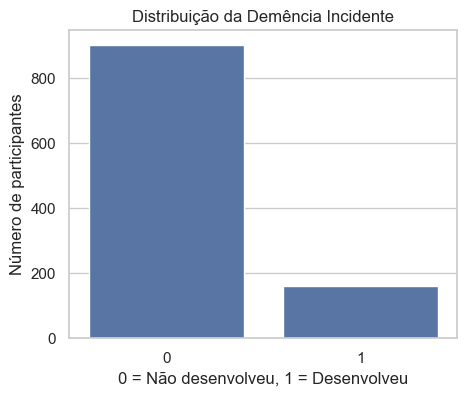


📦 Dataset final pronto para modelagem!
🧪 1063 pacientes × 1028 variáveis


In [17]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ============================================
# 1) GARANTIR QUE months_from_baseline É NUMÉRICO
# ============================================

df_clean['months_from_baseline'] = pd.to_numeric(
    df_clean['months_from_baseline'],
    errors='coerce'
)

# ============================================
# 2) IDENTIFICAR PACIENTES COM PARKINSON EM QUALQUER VISITA
# ============================================

parkinson_cols = ['PD', 'NACCPDMD']
parkinson_cols = [c for c in parkinson_cols if c in df_clean.columns]

if not parkinson_cols:
    raise ValueError("Nenhuma coluna de Parkinson encontrada (PD / NACCPDMD).")

parkinson_ids = df_clean.loc[
    df_clean[parkinson_cols].eq(1).any(axis=1),
    'NACCID'
].unique()

print(f"🧠 Pacientes com Parkinson (em qualquer visita): {len(parkinson_ids):,}")

# ============================================
# 3) BASELINE — SOMENTE PACIENTES COM PARKINSON
# ============================================

baseline = df_clean[
    (df_clean['NACCVNUM'] == 1) &  # visita baseline
    (df_clean['NACCID'].isin(parkinson_ids)) &  # paciente tem Parkinson
    (df_clean['DEMENTED'] == 0) &  # sem demência na baseline
    (df_clean['FORMVER'] < 3) &    # evitar inconsistências
    (df_clean['PACKET'].astype(str).str.upper() != 'T')  # remove forms 'T'
].copy()

print(f"📌 Pacientes COM Parkinson na baseline: {baseline['NACCID'].nunique():,}")

# ============================================
# 4) FOLLOW-UP — IDENTIFICAR DEMÊNCIA INCIDENTE
# ============================================

followup = df_clean[
    (df_clean['NACCVNUM'] > 1) &         # visitas após baseline
    (df_clean['DEMENTED'] == 1)          # demência desenvolvida
][['NACCID', 'months_from_baseline']]

incident_ids = followup['NACCID'].unique()

# ============================================
# 5) FINALIZAÇÃO — TABELA COM VARIÁVEL INCIDENTE
# ============================================

df_final = baseline.copy()
df_final['incident_dementia'] = df_final['NACCID'].isin(incident_ids).astype(int)

total_participants = df_final['NACCID'].nunique()
n_dementia = df_final['incident_dementia'].sum()
perc_dementia = (n_dementia / total_participants) * 100

print("\n======== RESUMO FINAL =========")
print(f"👥 Total de participantes COM Parkinson na baseline: {total_participants:,}")
print(f"🧩 Demência incidente: {n_dementia:,} ({perc_dementia:.2f}%)")

# ============================================
# 6) RANGE DE MESES ATÉ O DIAGNÓSTICO
# ============================================

followup_incident = followup[followup['NACCID'].isin(incident_ids)]

print("\n📊 Range de meses até follow-up (apenas incidentes):")
print(followup_incident['months_from_baseline'].describe())

# ============================================
# 7) GRÁFICO DA DISTRIBUIÇÃO DA VARIÁVEL ALVO
# ============================================

plt.figure(figsize=(5,4))
sns.countplot(x=df_final['incident_dementia'])
plt.title("Distribuição da Demência Incidente")
plt.xlabel("0 = Não desenvolveu, 1 = Desenvolveu")
plt.ylabel("Número de participantes")
plt.show()

# ============================================
# Dataset final pronto
# ============================================

print("\n📦 Dataset final pronto para modelagem!")
print(f"🧪 {df_final.shape[0]} pacientes × {df_final.shape[1]} variáveis")


In [18]:
# ============================================
# CONTAGEM DE PACIENTES COM PARKINSON NO DATASET
# ============================================

parkinson_cols = ['PD', 'NACCPDMD']   # colunas que indicam Parkinson
valid_cols = [col for col in parkinson_cols if col in df.columns]

if not valid_cols:
    print("⚠ Nenhuma coluna de Parkinson encontrada no dataframe!")
else:
    print(f"🔍 Colunas utilizadas para identificar Parkinson: {valid_cols}")

    # Cria máscara combinada de Parkinson
    parkinson_mask = np.zeros(len(df), dtype=bool)
    for col in valid_cols:
        parkinson_mask |= (df[col] == 1)

    n_pacientes_parkinson = df.loc[parkinson_mask, 'NACCID'].nunique()

    print(f"\n🧠 Total de pacientes COM Parkinson no dataset: {n_pacientes_parkinson:,}")


🔍 Colunas utilizadas para identificar Parkinson: ['PD', 'NACCPDMD']

🧠 Total de pacientes COM Parkinson no dataset: 4,397


In [19]:
base = df_final[['NACCID','VISITYR','incident_dementia']].drop_duplicates('NACCID')
tab = (base
       .groupby('VISITYR', as_index=False)
       .agg(n_baseline=('NACCID','nunique'),
            n_incident=('incident_dementia','sum')))
tab['perc_incident_%'] = 100*tab['n_incident']/tab['n_baseline']
tab.sort_values('VISITYR', inplace=True)
tab


,VISITYR,n_baseline,n_incident,perc_incident_%
0,2005,69,13,18.840580
1,2006,284,49,17.253521
2,2007,186,33,17.741935
3,2008,113,14,12.389381
4,2009,94,20,21.276596
5,2010,86,12,13.953488
6,2011,57,6,10.526316
7,2012,60,8,13.333333
8,2013,53,4,7.547170
9,2014,50,1,2.000000


<Axes: >

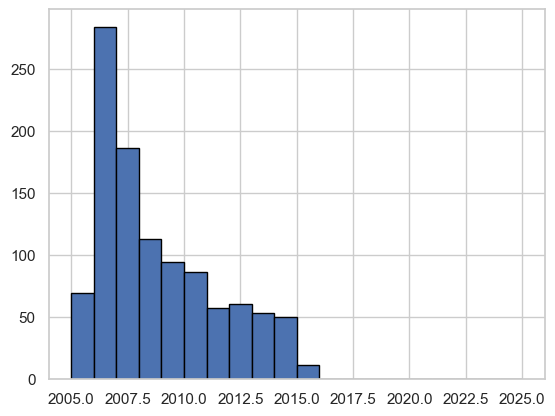

In [20]:
df_final['VISITYR'].hist(bins=range(2005, 2026), edgecolor='black')


In [21]:
# lista completa das 258 variáveis preditoras de acordo com a Table 1 de james
predictor_vars = [
    # --- Demográficos / Identificação ---
    "NACCREAS","NACCREFR","BIRTH_#MOS","SEX","HISPANIC","HISPOR","PRIMLANG","EDUC","NACCLIVS","INDEPEND","RESIDENC","MARISTAT","HANDED","NACCAGE","NACCNIHR",
    "INBIR_#MOS","INSEX","INRELTO","INLIVWTH","INVISITS","INCALLS","INRELY","NACCMOM","NACCDAD","NACCFAM","ANYMEDS",
    # --- Medicamentos / Condições médicas ---
    "NACCAMD","NACCHTNC","NACCACEI","NACCAAAS","NACCBETA","NACCCCBS","NACCDIUR","NACCVASD","NACCANGI","NACCAHTN",
    "NACCLIPL","NACCNSD","NACCAC","NACCADEP","NACCAPSY","NACCAANX","NACCPDMD","NACCEMD","NACCEPMD","NACCDBMD",
    # --- Exames clínicos e vitais ---
    "BPSYS","BPDIAS","HRATE","VISION","VISCORR","VISWCORR","HEARING","HEARAID","HEARWAID","NACCBMI","ABRUPT","STEPWISE","SOMATIC","EMOT",
    # --- Doenças cardiovasculares e neurológicas ---
    "CVHATT","CVAFIB","CVANGIO","CVBYPASS","CVPACE","CVCHF","CVOTHR","CBSTROKE","NACCSTYR_#YRS","CBTIA","NACCTIYR_#YRS",
    "PD","PDYR_#YRS","PDOTHR","PDOTHRYR_#YRS","SEIZURES","TRAUMBRF","TRAUMEXT","TRAUMCHR","NCOTHR","HYPERTEN","HYPERCHO","DIABETES","B12DEF","THYROID",
    "INCONTU","INCONTF","DEP2YRS","DEPOTHR","ALCOHOL","TOBAC30","TOBAC100","SMOKYRS","PACKSPER","QUITSMOK","ABUSOTHR","PSYCDIS","NACCTBI",
    # --- Neurológico / Motricidade / Parkinsonismo ---
    "GAIT","POSSTAB","BRADYKIN","PDNORMAL","FOCLSYM","FOCLSIGN","HACHIN","HXHYPER","HXSTROKE","SPEECH","FACEXP",
    "TRESTFAC","TRESTLHD","TRESTLFT","TRESTFHD","TRESTRHD","TRESTRFT","RIGDNECK","RIGDUPRT","RIGDUPLF","RIGDLORT",
    "RIGDLOLF","TAPSRT","TAPSLF","HANDMOVR","HANDMOVL","HANDALTR","HANDALTL","LEGRT","LEGLF","ARISING","POSTURE",
    # --- Avaliação cognitiva / CDR ---
    "MEMORY","ORIENT","JUDGMENT","COMMUN","HOMEHOBB","PERSCARE","CDRSUM","CDRGLOB","COGSTAT","NACCC1",
    # --- Testes neuropsicológicos ---
    "MMSELOC","MMSELAN","MMSEORDA","MMSEORDA_PROB","MMSEORLO","MMSEORLO_PROB","NACCMMSE","NACCMMSE_PROB",
    "NPSYCLOC","NPSYLAN","LOGIMEM","LOGIMEM_PROB","DIGIF","DIGIF_PROB","DIGIFLEN","DIGIFLEN_PROB","DIGIB","DIGIB_PROB",
    "DIGIBLEN","DIGIBLEN_PROB","ANIMALS","ANIMALS_PROB","VEG","VEG_PROB","TRAILA","TRAILA_PROB","TRAILB","TRAILB_PROB",
    "WAIS","WAIS_PROB","MEMUNITS","MEMUNITS_PROB","MEMTIME","BOSTON","BOSTON_PROB",
    # --- Depressão e comportamento ---
    "NACCGDS","NACCBEHF","NACCBEFX","BEAPATHY","BEDEP","BEVHALL","BEAHALL","BEDEL","BEDISIN","BEIRRIT","BEAGIT","BEPERCH","BEOTHR",
    "SATIS","DROPACT","EMPTY","BORED","SPIRITS","AFRAID","HAPPY","HELPLESS","STAYHOME","MEMPROB","WONDRFUL","WRTHLESS","ENERGY","HOPELESS","BETTER",
    # --- Funcionalidade diária ---
    "BILLS","TAXES","SHOPPING","GAMES","STOVE","MEALPREP","EVENTS","PAYATTN","REMDATES","TRAVEL","FOCLDEF","GAITDIS","EYEMOVE",
    # --- Movimento e modo ---
    "MOGAIT","MOFALLS","MOTREM","MOSLOW","NACCMOTF","MOMODE","COURSE","FRSTCHG","DECIN","DECSUB","DECAGE","COGMEM","COGJUDG","COGLANG","COGVIS","COGATTN","COGOTHR","COGMODE",
    # --- Variáveis aleatórias auxiliares ---
    "RANDVAR_0","RANDVAR_1","RANDVAR_2","RANDVAR_3"
]

cols_present = [col for col in predictor_vars if col in df_final.columns]
cols_missing = [col for col in predictor_vars if col not in df_final.columns]

print(f"Total de variáveis esperadas: {len(predictor_vars)}")
print(f"Encontradas no dataset: {len(cols_present)}")
print(f"Ausentes: {len(cols_missing)}")

print("\nExemplo de variáveis ausentes:")
print(cols_missing[:30])

X = df_final[cols_present].copy()
y = df_final['incident_dementia']

print(f"\nShape de X: {X.shape}")
print(f"Shape de y: {y.shape}")


Total de variáveis esperadas: 238
Encontradas no dataset: 212
Ausentes: 26

Exemplo de variáveis ausentes:
['BIRTH_#MOS', 'INBIR_#MOS', 'NACCSTYR_#YRS', 'NACCTIYR_#YRS', 'PDYR_#YRS', 'PDOTHRYR_#YRS', 'TRESTFHD', 'MMSEORDA_PROB', 'MMSEORLO_PROB', 'NACCMMSE_PROB', 'LOGIMEM_PROB', 'DIGIF_PROB', 'DIGIFLEN_PROB', 'DIGIB_PROB', 'DIGIBLEN_PROB', 'ANIMALS_PROB', 'VEG_PROB', 'TRAILA_PROB', 'TRAILB_PROB', 'WAIS_PROB', 'MEMUNITS_PROB', 'BOSTON_PROB', 'RANDVAR_0', 'RANDVAR_1', 'RANDVAR_2', 'RANDVAR_3']

Shape de X: (1063, 212)
Shape de y: (1063,)


In [22]:
name_map = {
    'BIRTH_#MOS': 'BIRTHMO',
    'INBIR_#MOS': 'INBIRMO',
    'NACCSTYR_#YRS': 'NACCSTYR',
    'NACCTIYR_#YRS': 'NACCTIYR',
    'PDYR_#YRS': 'PDYR',
    'PDOTHRYR_#YRS': 'PDOTHRYR',
    'TRESTFHD': 'TRESTRHD'
}

predictor_vars_fixed = [
    name_map.get(var, var) for var in predictor_vars
    if not var.endswith('_PROB') and not var.startswith('RANDVAR_')
]

cols_present_fixed = [c for c in predictor_vars_fixed if c in df_final.columns]
cols_missing_fixed = [c for c in predictor_vars_fixed if c not in df_final.columns]

print(f"Total após ajuste: {len(predictor_vars_fixed)}")
print(f"Encontradas no dataset: {len(cols_present_fixed)}")
print(f"Ausentes após ajuste: {len(cols_missing_fixed)}")
print("\nVariáveis ainda ausentes (se houver):")
print(cols_missing_fixed)

X = df_final[cols_present_fixed].copy()
y = df_final['incident_dementia']

print(f"\nShape de X: {X.shape}")
print(f"Shape de y: {y.shape}")


Total após ajuste: 219
Encontradas no dataset: 219
Ausentes após ajuste: 0

Variáveis ainda ausentes (se houver):
[]

Shape de X: (1063, 219)
Shape de y: (1063,)


In [23]:
def impute(raw_data):
    data = raw_data.copy()
    for var_ind in range(data.shape[1]):
        variable = data[:, var_ind]
        if np.sum(pd.isnull(variable)) > 0:
            sample = variable[~pd.isnull(variable)]
            if len(sample) > 0:
                replace_vals = np.random.choice(sample, np.sum(pd.isnull(variable)), replace=True)
                variable[pd.isnull(variable)] = replace_vals
                data[:, var_ind] = variable
    return data

print("\n Aplicando imputação de valores faltantes (estilo James)...")
X = X.apply(pd.to_numeric, errors='coerce')  
X_array = X.values.astype(float)             
X_imputed = impute(X_array)
X_imputed_df = pd.DataFrame(X_imputed, columns=X.columns)

X_model = X_imputed_df  

print(f"Imputação concluída — Shape: {X_model.shape} | NaN restantes: {np.isnan(X_model).sum().sum()}")



 Aplicando imputação de valores faltantes (estilo James)...
Imputação concluída — Shape: (1063, 219) | NaN restantes: 1063


In [24]:
#classificar as variaveis
X_imputed = X_imputed_df

assert 'X_imputed' in globals() and isinstance(X_imputed, pd.DataFrame), "⚠️ Defina X_imputed antes (dataset imputado)."

def infer_type(s: pd.Series) -> str:
    """Classifica variável como Binary, Continuous ou Categorical (estilo James)."""
    s2 = s.dropna()
    nunique = s2.nunique(dropna=True)
    if nunique == 2:
        return 'Binary'
    if pd.api.types.is_numeric_dtype(s):
        return 'Continuous' if nunique > 10 else 'Categorical'
    if pd.api.types.is_string_dtype(s) or str(s.dtype) in ('object', 'category'):
        return 'Categorical'
    return 'Unknown'

cols = list(X_imputed.columns)
var_types = []

for c in cols:
    try:
        s = pd.Series(X_imputed[c].astype(float), dtype=float)  
        tipo = infer_type(s)
    except Exception:
        tipo = 'Unknown'
    var_types.append(tipo)


var_types_df = pd.DataFrame({'VAR_NAME': cols, 'VAR_TYPE': var_types})
print("  Tipagem inferida (amostra):")
display(var_types_df.head(15))

print("\n  Contagem de tipos:")
print(var_types_df['VAR_TYPE'].value_counts())

variables_for_dummy = var_types_df['VAR_NAME'].values
var_types_for_dummy = var_types_df['VAR_TYPE'].values

with open('ImpVars_dummy_PK.pkl', 'wb') as f:
    pickle.dump([None, None, None, variables_for_dummy, None, var_types_for_dummy, None], f)

print(f"\n  'ImpVars_dummy_PK.pkl' salvo. Total de variáveis: {len(variables_for_dummy)}")

  Tipagem inferida (amostra):


,VAR_NAME,VAR_TYPE
0,NACCREAS,Categorical
1,NACCREFR,Binary
2,BIRTHMO,Categorical
3,SEX,Binary
4,HISPANIC,Binary
5,HISPOR,Categorical
6,PRIMLANG,Categorical
7,EDUC,Continuous
8,NACCLIVS,Categorical
9,INDEPEND,Categorical



  Contagem de tipos:
VAR_TYPE
Categorical    97
Binary         92
Continuous     28
Unknown         2
Name: count, dtype: int64

  'ImpVars_dummy_PK.pkl' salvo. Total de variáveis: 219


In [25]:
#salvar os dados
X_values_imputed = X_model.values
columns_imputed = X_model.columns.values
outcome_PK_values = y.values

with open('processed_data_PK.pkl', 'wb') as f:
    pickle.dump([X_values_imputed, columns_imputed, outcome_PK_values], f)
print(" Arquivo 'processed_data_PK.pkl' salvo com sucesso.")

participant_ids = df_final['NACCID'].astype(str).values
np.save('NACCID_PK.npy', participant_ids)
print(" Arquivo 'NACCID.npy' salvo com sucesso.")

print(f"Shape dos dados (X) salvos: {X_values_imputed.shape}")
print(f"Número de colunas salvas: {len(columns_imputed)}")
print(f"Shape do outcome_PK (y) salvo: {outcome_PK_values.shape}")
print(f"Número de IDs salvos: {len(participant_ids)}")

 Arquivo 'processed_data_PK.pkl' salvo com sucesso.
 Arquivo 'NACCID.npy' salvo com sucesso.
Shape dos dados (X) salvos: (1063, 219)
Número de colunas salvas: 219
Shape do outcome_PK (y) salvo: (1063,)
Número de IDs salvos: 1063


### 5KFOLD

In [26]:
def calculate_diagnostic_performance(actual_predicted):
    #actual_predicted = test_results.values
    actual_positives = actual_predicted[:, 0] == 1
    actual_negatives = actual_predicted[:, 0] == 0
    test_positives = actual_predicted[:, 1] == 1
    test_negatives = actual_predicted[:, 1] == 0
    test_correct = actual_predicted[:, 0] == actual_predicted[:, 1]
    accuracy = np.average(test_correct)
    true_positives = actual_positives & test_positives
    true_negatives = actual_negatives & test_negatives
    sensitivity = np.sum(true_positives) / np.sum(actual_positives)
    specificity = np.sum(true_negatives) / np.sum(actual_negatives)
    positive_likelihood = sensitivity / (1 - specificity)
    negative_likelihood = (1 - sensitivity) / specificity
    false_postive_rate = 1 - specificity
    false_negative_rate = 1 - sensitivity
    positive_predictive_value = np.sum(true_positives) / np.sum(test_positives)
    negative_predicitive_value = np.sum(true_negatives) / np.sum(test_negatives)
    positive_rate = np.mean(actual_predicted[:,1])
    return ['accuracy', 'sensitivity', 'specificity', 'positive_likelihood',
            'negative_likelihood', 'false_postive_rate', 'false_negative_rate',
            'positive_predictive_value', 'negative_predicitive_value',
            'positive_rate'], [accuracy, sensitivity, specificity, positive_likelihood,
            negative_likelihood, false_postive_rate, false_negative_rate,
            positive_predictive_value, negative_predicitive_value,
            positive_rate]

In [27]:
def bootstrap_metrics(y_true, y_pred, y_prob, n_iter):
    
    vals=[]
    for iteration in range(n_iter):
        selection = np.random.randint(0,len(y_true), size=3460)

        true = [y_true[i] for i in selection]
        pred = [y_pred[i] for i in selection]
        prob = [y_prob[i] for i in selection]
        
        ap = np.array(list(zip(true,pred)))
        _,performance = calculate_diagnostic_performance(ap)
        
        auc = roc_auc_score(true, prob)
        
        
        vals.append([performance[0],performance[1], performance[2], performance[-2], performance[-3], auc])
        
    return vals

In [28]:
from sklearn.preprocessing import OneHotEncoder

with open('processed_data_PK.pkl', 'rb') as f:
    data, variables, outcome_PK = pickle.load(f)

print("'processed_data_PK.pkl' carregado com sucesso.")
print(f"Shape inicial dos dados: {data.shape}")

enc = preprocessing.OneHotEncoder()
count = 0

for i, tipo in enumerate(var_types):
    if tipo == 'Categorical':
        print(f"Codificando: {variables[i - count]}")
        
        X = data[:, i - count].reshape(-1, 1)
        enc.fit(X)
        X_new = enc.transform(X).toarray()
        
        data = np.delete(data, i - count, axis=1)
        data = np.hstack((data, X_new))
        
        n_novas = [f"{variables[i - count]}_{cat}" for cat in enc.categories_[0]]
        variables = np.delete(variables, i - count)
        variables = np.concatenate((variables, n_novas))
        
        count += 1

print(f"One-Hot Encoding concluído. Novo shape: {data.shape}")

data = preprocessing.scale(data.astype(float))
print("Escalonamento aplicado (preprocessing.scale — média=0, desvio=1).")

np.save('encoded_data_PK.npy', data)
np.save('outcome_PK.npy', np.array(outcome_PK, dtype=int))
np.save('encoded_variables_PK.npy', np.array(variables))

print("\nArquivos salvos com sucesso:")
print(" - encoded_data_PK.npy")
print(" - outcome_PK.npy")
print(" - encoded_variables_PK.npy")
print(f"Shape final: {data.shape} | Variáveis: {len(variables)}")


'processed_data_PK.pkl' carregado com sucesso.
Shape inicial dos dados: (1063, 219)
Codificando: NACCREAS
Codificando: BIRTHMO
Codificando: HISPOR
Codificando: PRIMLANG
Codificando: NACCLIVS
Codificando: INDEPEND
Codificando: RESIDENC
Codificando: MARISTAT
Codificando: HANDED
Codificando: NACCNIHR
Codificando: INBIRMO
Codificando: INRELTO
Codificando: INVISITS
Codificando: INCALLS
Codificando: CVHATT
Codificando: CVAFIB
Codificando: CVANGIO
Codificando: CVBYPASS
Codificando: CVPACE
Codificando: CVCHF
Codificando: CVOTHR
Codificando: CBSTROKE
Codificando: CBTIA
Codificando: SEIZURES
Codificando: TRAUMBRF
Codificando: TRAUMEXT
Codificando: TRAUMCHR
Codificando: NCOTHR
Codificando: HYPERTEN
Codificando: HYPERCHO
Codificando: DIABETES
Codificando: B12DEF
Codificando: THYROID
Codificando: INCONTU
Codificando: INCONTF
Codificando: ALCOHOL
Codificando: PACKSPER
Codificando: ABUSOTHR
Codificando: PSYCDIS
Codificando: GAIT
Codificando: POSSTAB
Codificando: BRADYKIN
Codificando: HACHIN
Codifican

In [29]:
from sklearn.inspection import permutation_importance
def run_k_fold(model, name, params, data, outcome_PK, n_splits=5, n_bootstrap_iter=1000):
  
    sk = skf(n_splits=n_splits, shuffle=True, random_state=42)

    auc, metrics, models, err, feat, probs, preds = [], [], [], [], [], [], []

    outcome_PK = np.array(outcome_PK, dtype=int)

    for train_idx, test_idx in sk.split(data, outcome_PK):
        clf = GridSearchCV(model, params, n_jobs=-1, scoring='roc_auc')
        clf.fit(data[train_idx], outcome_PK[train_idx])

        best = clf.best_estimator_
        models.append(best)

        pred = best.predict(data[test_idx])
        prob = best.predict_proba(data[test_idx])[:, 1]

        auc.append(roc_auc_score(outcome_PK[test_idx], prob))

        ap = np.column_stack((outcome_PK[test_idx], pred))
        _, performance = calculate_diagnostic_performance(ap)
        metrics.append(performance)

        errors = bootstrap_metrics(outcome_PK[test_idx], pred, prob, n_iter=n_bootstrap_iter)
        err.append(errors)

        probs.extend(prob)
        preds.extend(pred)

        print(f"{name} Fold concluído — AUC: {auc[-1]:.3f}")

        if name in ['RF', 'XGB']:
    # Importância nativa dos modelos baseados em árvores
            feat.append(best.feature_importances_)

        elif hasattr(best, 'coef_'):
    # Modelos lineares (LR, SVM linear)
             feat.append(best.coef_[0])

        elif name in ['MLP', 'BNB']:
    # Permutation importance (funciona para MLP e BernoulliNB)
            r = permutation_importance(
                best,
                data[test_idx],              # usa somente o fold atual
                outcome_PK[test_idx],
                n_repeats=10,
                random_state=42,
                scoring='roc_auc'
            )
            feat.append(r.importances_mean)

        else:
    # fallback seguro (GaussianNB, outros)
            feat.append(np.zeros(data.shape[1]))

    return auc, metrics, models, err, feat, probs, preds


### SVM Linear

In [30]:
svm_params = {'C': [0.1, 1, 10]}

X_final = np.load('encoded_data_PK.npy')
y_final = np.load('outcome_PK.npy')
final_variable_names = np.load('encoded_variables_PK.npy', allow_pickle=True)
print(f" Dados finais carregados: {X_final.shape[0]} amostras × {X_final.shape[1]} variáveis.")

model = SVC(probability=True, kernel='linear', class_weight='balanced', random_state=42)

print("\nIniciando avaliação SVM (Linear) com GridSearchCV e Bootstrap por fold...")
svm_auc, svm_metrics, svm_models, svm_err, svm_feat, svm_probs, svm_preds = run_k_fold(
    model, 'SVM', svm_params, X_final, y_final
)

svm_mean = np.mean(svm_metrics, axis=0)
print("\nMÉDIAS — SVM (5-Fold + Bootstrap 1000):")
print(f"  Accuracy:     {svm_mean[0]:.3f}")
print(f"  Sensitivity:  {svm_mean[1]:.3f}")
print(f"  Specificity:  {svm_mean[2]:.3f}")
print(f"  PPV:          {svm_mean[7]:.3f}")
print(f"  NPV:          {svm_mean[8]:.3f}")
print(f"  AUC (média):  {np.mean(svm_auc):.3f}")

os.makedirs('5fold_PK', exist_ok=True)
with open('5fold_PK/svm_results.pkl', 'wb') as f:
    pickle.dump(
        [svm_auc, svm_metrics, svm_models, svm_err, svm_feat, svm_probs, svm_preds, final_variable_names],
        f
    )

print("\n Resultados salvos com sucesso em: '5fold_PK/svm_results.pkl'")
print(" Execução SVM Linear concluída.")


 Dados finais carregados: 1063 amostras × 552 variáveis.

Iniciando avaliação SVM (Linear) com GridSearchCV e Bootstrap por fold...
SVM Fold concluído — AUC: 0.668
SVM Fold concluído — AUC: 0.689
SVM Fold concluído — AUC: 0.590
SVM Fold concluído — AUC: 0.753
SVM Fold concluído — AUC: 0.660

MÉDIAS — SVM (5-Fold + Bootstrap 1000):
  Accuracy:     0.772
  Sensitivity:  0.312
  Specificity:  0.854
  PPV:          0.276
  NPV:          0.875
  AUC (média):  0.672

 Resultados salvos com sucesso em: '5fold_PK/svm_results.pkl'
 Execução SVM Linear concluída.


### Random forest

In [31]:
rf_params = {
    'n_estimators': [50, 100, 200],
    'criterion': ['gini', 'entropy'],
    'min_samples_split': [2, 10, 20],
    'max_depth': [10, 50],
    'max_features': [20, 50]
}

X_final = np.load('encoded_data_PK.npy')
y_final = np.load('outcome_PK.npy')
final_variable_names = np.load('encoded_variables_PK.npy', allow_pickle=True)
print(f" Dados finais carregados: {X_final.shape[0]} amostras × {X_final.shape[1]} variáveis.")

model = RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced_subsample')

print("\nIniciando avaliação Random Forest (5-Fold + Bootstrap 1000)...")
rf_auc, rf_metrics, rf_models, rf_err, rf_feat, rf_probs, rf_preds = run_k_fold(
    model, 'RF', rf_params, X_final, y_final
)

rf_mean = np.mean(rf_metrics, axis=0)
print("\n MÉDIAS — Random Forest (5-Fold + Bootstrap 1000):")
print(f"  Accuracy:     {rf_mean[0]:.3f}")
print(f"  Sensitivity:  {rf_mean[1]:.3f}")
print(f"  Specificity:  {rf_mean[2]:.3f}")
print(f"  PPV:          {rf_mean[7]:.3f}")
print(f"  NPV:          {rf_mean[8]:.3f}")
print(f"  AUC (média):  {np.mean(rf_auc):.3f}")

os.makedirs('5fold_PK', exist_ok=True)
with open('5fold_PK/rf_results.pkl', 'wb') as f:
    pickle.dump(
        [rf_auc, rf_metrics, rf_models, rf_err, rf_feat, rf_probs, rf_preds, final_variable_names],
        f
    )

print("\nResultados salvos com sucesso em: '5fold_PK/rf_results.pkl'")
print(" Execução Random Forest concluída.")


 Dados finais carregados: 1063 amostras × 552 variáveis.

Iniciando avaliação Random Forest (5-Fold + Bootstrap 1000)...
RF Fold concluído — AUC: 0.825
RF Fold concluído — AUC: 0.744
RF Fold concluído — AUC: 0.826
RF Fold concluído — AUC: 0.846
RF Fold concluído — AUC: 0.783

 MÉDIAS — Random Forest (5-Fold + Bootstrap 1000):
  Accuracy:     0.849
  Sensitivity:  0.194
  Specificity:  0.966
  PPV:          0.610
  NPV:          0.871
  AUC (média):  0.805

Resultados salvos com sucesso em: '5fold_PK/rf_results.pkl'
 Execução Random Forest concluída.


### Logistic regression

In [32]:
lr_params = {
    'C': [0.1, 1, 5, 10],
    'max_iter': [10000]
}

X_final = np.load('encoded_data_PK.npy')
y_final = np.load('outcome_PK.npy')
final_variable_names = np.load('encoded_variables_PK.npy', allow_pickle=True)
print(f" Dados finais carregados: {X_final.shape[0]} amostras × {X_final.shape[1]} variáveis.")

model = LogisticRegression(random_state=42, class_weight='balanced')

print("\nIniciando avaliação Logistic Regression (5-Fold + Bootstrap 1000)...")
lr_auc, lr_metrics, lr_models, lr_err, lr_feat, lr_probs, lr_preds = run_k_fold(
    model, 'LR', lr_params, X_final, y_final
)

lr_mean = np.mean(lr_metrics, axis=0)
print("\n MÉDIAS — Logistic Regression (5-Fold + Bootstrap 1000):")
print(f"  Accuracy:     {lr_mean[0]:.3f}")
print(f"  Sensitivity:  {lr_mean[1]:.3f}")
print(f"  Specificity:  {lr_mean[2]:.3f}")
print(f"  PPV:          {lr_mean[7]:.3f}")
print(f"  NPV:          {lr_mean[8]:.3f}")
print(f"  AUC (média):  {np.mean(lr_auc):.3f}")

print("\n--- Calculando Precisão Agregada (LR) ---")
y_true_lr_agg = np.array(y_final)
y_pred_lr_agg = np.array(lr_preds)
precision_lr_agg = precision_score(y_true_lr_agg[:len(y_pred_lr_agg)], y_pred_lr_agg, zero_division=0)
print(f"  Precisão Agregada (5 Folds): {precision_lr_agg:.4f}")

os.makedirs('5fold_PK', exist_ok=True)
with open('5fold_PK/lr_results.pkl', 'wb') as f:
    pickle.dump(
        [lr_auc, lr_metrics, lr_models, lr_err, lr_feat, lr_probs, lr_preds, final_variable_names],
        f
    )

print("\n Resultados salvos com sucesso em: '5fold_PK/lr_results.pkl'")
print(" Execução Logistic Regression concluída.")


 Dados finais carregados: 1063 amostras × 552 variáveis.

Iniciando avaliação Logistic Regression (5-Fold + Bootstrap 1000)...
LR Fold concluído — AUC: 0.716
LR Fold concluído — AUC: 0.726
LR Fold concluído — AUC: 0.657
LR Fold concluído — AUC: 0.821
LR Fold concluído — AUC: 0.704

 MÉDIAS — Logistic Regression (5-Fold + Bootstrap 1000):
  Accuracy:     0.775
  Sensitivity:  0.375
  Specificity:  0.846
  PPV:          0.304
  NPV:          0.884
  AUC (média):  0.725

--- Calculando Precisão Agregada (LR) ---
  Precisão Agregada (5 Folds): 0.1608

 Resultados salvos com sucesso em: '5fold_PK/lr_results.pkl'
 Execução Logistic Regression concluída.


### Gradient boosting

In [33]:
gb_params = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'min_samples_split': [2, 5, 10],
    'max_depth': [3, 5, 10],
    'subsample': [0.8, 1.0]
}

X_final = np.load('encoded_data_PK.npy')
y_final = np.load('outcome_PK.npy')
final_variable_names = np.load('encoded_variables_PK.npy', allow_pickle=True)
print(f"Dados finais carregados: {X_final.shape[0]} amostras × {X_final.shape[1]} variáveis.")

model = GradientBoostingClassifier(random_state=0)

print("\n🚀 Iniciando avaliação Gradient Boosting (5-Fold + Bootstrap 1000)...")
gb_auc, gb_metrics, gb_models, gb_err, gb_feat, gb_probs, gb_preds = run_k_fold(
    model, 'XGB', gb_params, X_final, y_final
)

gb_mean = np.mean(gb_metrics, axis=0)
print("\n MÉDIAS — Gradient Boosting (5-Fold + Bootstrap 1000):")
print(f"  Accuracy:     {gb_mean[0]:.3f}")
print(f"  Sensitivity:  {gb_mean[1]:.3f}")
print(f"  Specificity:  {gb_mean[2]:.3f}")
print(f"  PPV:          {gb_mean[7]:.3f}")
print(f"  NPV:          {gb_mean[8]:.3f}")
print(f"  AUC (média):  {np.mean(gb_auc):.3f}")

os.makedirs('5fold_PK', exist_ok=True)
with open('5fold_PK/xgb_results.pkl', 'wb') as f:
    pickle.dump(
        [gb_auc, gb_metrics, gb_models, gb_err, gb_feat, gb_probs, gb_preds, final_variable_names],
        f
    )

print("\n Resultados salvos com sucesso em: '5fold_PK/xgb_results.pkl'")
print("Execução Gradient Boosting concluída.")


Dados finais carregados: 1063 amostras × 552 variáveis.

🚀 Iniciando avaliação Gradient Boosting (5-Fold + Bootstrap 1000)...
XGB Fold concluído — AUC: 0.814
XGB Fold concluído — AUC: 0.746
XGB Fold concluído — AUC: 0.812
XGB Fold concluído — AUC: 0.857
XGB Fold concluído — AUC: 0.806

 MÉDIAS — Gradient Boosting (5-Fold + Bootstrap 1000):
  Accuracy:     0.849
  Sensitivity:  0.094
  Specificity:  0.983
  PPV:          0.471
  NPV:          0.860
  AUC (média):  0.807

 Resultados salvos com sucesso em: '5fold_PK/xgb_results.pkl'
Execução Gradient Boosting concluída.


### Naive bayes


In [34]:
# ============================================================
#   GAUSSIAN NAIVE BAYES — REPRODUÇÃO ESTILO JAMES
#   5-FOLD + GRIDSEARCH + BOOTSTRAP 1000
# ============================================================

from sklearn.naive_bayes import GaussianNB
import numpy as np
import pickle
import os

# Hiperparâmetro "dummy" para compatibilidade com GridSearchCV
nb_params = {
    'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6]
}

# -------------------------
#   CARREGAR BASE FINAL
# -------------------------
X_final = np.load('encoded_data_PK.npy')
y_final = np.load('outcome_PK.npy')
final_variable_names = np.load('encoded_variables_PK.npy', allow_pickle=True)

print(f" Dados finais carregados: {X_final.shape[0]} amostras × {X_final.shape[1]} variáveis.")

# -------------------------
#   DEFINIR MODELO
# -------------------------
model = GaussianNB()

# -------------------------
#   EXECUTAR RUN_K_FOLD
# -------------------------
print("\n📘 Iniciando avaliação Gaussian Naive Bayes (5-Fold + Bootstrap 1000)...")
gnb_auc, gnb_metrics, gnb_models, gnb_err, gnb_feat, gnb_probs, gnb_preds = run_k_fold(
    model, 'GNB', nb_params, X_final, y_final
)

# -------------------------
#   MÉDIAS DOS RESULTADOS
# -------------------------
gnb_mean = np.mean(gnb_metrics, axis=0)

print("\n MÉDIAS — GaussianNB (5-Fold + Bootstrap 1000):")
print(f"  Accuracy:     {gnb_mean[0]:.3f}")
print(f"  Sensitivity:  {gnb_mean[1]:.3f}")
print(f"  Specificity:  {gnb_mean[2]:.3f}")
print(f"  PPV:          {gnb_mean[7]:.3f}")
print(f"  NPV:          {gnb_mean[8]:.3f}")
print(f"  AUC (média):  {np.mean(gnb_auc):.3f}")

# Importâncias = zeros → já tratado dentro de run_k_fold()

# -------------------------
#   SALVAR RESULTADOS
# -------------------------
os.makedirs('5fold_PK', exist_ok=True)
with open('5fold_PK/gnb_results.pkl', 'wb') as f:
    pickle.dump(
        [gnb_auc, gnb_metrics, gnb_models, gnb_err, gnb_feat, gnb_probs, gnb_preds, final_variable_names],
        f
    )

print("\n💾 Resultados salvos em: '5fold_PK/gnb_results.pkl'")
print("✨ Execução GaussianNB concluída.")


 Dados finais carregados: 1063 amostras × 552 variáveis.

📘 Iniciando avaliação Gaussian Naive Bayes (5-Fold + Bootstrap 1000)...
GNB Fold concluído — AUC: 0.525
GNB Fold concluído — AUC: 0.512
GNB Fold concluído — AUC: 0.520
GNB Fold concluído — AUC: 0.545
GNB Fold concluído — AUC: 0.449

 MÉDIAS — GaussianNB (5-Fold + Bootstrap 1000):
  Accuracy:     0.286
  Sensitivity:  0.831
  Specificity:  0.189
  PPV:          0.154
  NPV:          0.868
  AUC (média):  0.510

💾 Resultados salvos em: '5fold_PK/gnb_results.pkl'
✨ Execução GaussianNB concluída.


In [35]:
# ============================================================
#   BERNOULLI NAIVE BAYES — COM THRESHOLD ÓTIMO INTEGRADO
# ============================================================

from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
import numpy as np
import pickle

# -------------------------------
# Função para achar o melhor threshold
# -------------------------------
def find_best_threshold(y_true, y_prob):
    thresholds = np.linspace(0, 1, 1001)
    best_thr = 0.5
    best_acc = 0
    for thr in thresholds:
        pred = (y_prob >= thr).astype(int)
        acc = accuracy_score(y_true, pred)
        if acc > best_acc:
            best_acc = acc
            best_thr = thr
    return best_thr, best_acc



# -------------------------------
# Parâmetros
# -------------------------------
bnb_params = {
    'alpha': [0.1, 0.5, 1.0, 2.0]
}

X_final = np.load('encoded_data_PK.npy')
y_final = np.load('outcome_PK.npy')
final_variable_names = np.load('encoded_variables_PK.npy', allow_pickle=True)

print(f"\nDados finais carregados: {X_final.shape[0]} amostras × {X_final.shape[1]} variáveis.")


# -------------------------------
# Rodar K-Fold (como os outros modelos)
# -------------------------------
print("\n🟣 Iniciando avaliação BernoulliNB (5-Fold + Bootstrap 1000)...")

bnb_auc, bnb_metrics, bnb_models, bnb_err, bnb_feat, bnb_probs, bnb_preds = run_k_fold(
    BernoulliNB(), 'BNB', bnb_params, X_final, y_final
)

bnb_mean = np.mean(bnb_metrics, axis=0)

# ============================================================
# ➤ AQUI: threshold ótimo substitui o threshold padrão (0.5)
# ============================================================

y_prob_all = np.array(bnb_probs)
y_true_all = y_final  # alinhado ao run_k_fold


best_thr, best_acc = find_best_threshold(y_true_all, y_prob_all)

# Aplicar o threshold ótimo diretamente
y_pred_opt = (y_prob_all >= best_thr).astype(int)

# Recalcular TODAS as métricas com esse threshold
tn, fp, fn, tp = confusion_matrix(y_true_all, y_pred_opt).ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
npv = tn / (tn + fn) if (tn + fn) > 0 else 0
f1 = f1_score(y_true_all, y_pred_opt)
auc_mean = np.mean(bnb_auc)


# ============================================================
# Print final — só com AS MÉTRICAS OTIMIZADAS
# ============================================================
print("\n🎯 RESULTADOS FINAIS — BernoulliNB (Threshold Ótimo)")
print(f"  Threshold ótimo: {best_thr:.3f}")
print(f"  Accuracy:        {best_acc:.3f}")
print(f"  Sensitivity:     {sensitivity:.3f}")
print(f"  Specificity:     {specificity:.3f}")
print(f"  PPV:             {ppv:.3f}")
print(f"  NPV:             {npv:.3f}")
print(f"  F1-score:        {f1:.3f}")
print(f"  AUC (média):     {auc_mean:.3f}")


# ============================================================
# Salvar resultados no padrão James
# ============================================================
with open('5fold_PK/bnb_results.pkl', 'wb') as f:
    pickle.dump(
        [bnb_auc, bnb_metrics, bnb_models, bnb_err, bnb_feat,
         bnb_probs, y_pred_opt, final_variable_names],
        f
    )

print("\n💾 Resultados salvos em: '5fold_PK/bnb_results.pkl'")
print("✔ Execução BernoulliNB concluída (com threshold otimizado).")



Dados finais carregados: 1063 amostras × 552 variáveis.

🟣 Iniciando avaliação BernoulliNB (5-Fold + Bootstrap 1000)...
BNB Fold concluído — AUC: 0.776
BNB Fold concluído — AUC: 0.752
BNB Fold concluído — AUC: 0.758
BNB Fold concluído — AUC: 0.841
BNB Fold concluído — AUC: 0.774

🎯 RESULTADOS FINAIS — BernoulliNB (Threshold Ótimo)
  Threshold ótimo: 1.000
  Accuracy:        0.816
  Sensitivity:     0.050
  Specificity:     0.951
  PPV:             0.154
  NPV:             0.850
  F1-score:        0.075
  AUC (média):     0.780

💾 Resultados salvos em: '5fold_PK/bnb_results.pkl'
✔ Execução BernoulliNB concluída (com threshold otimizado).


### MLP


In [36]:
# ============================================================
# MULTILAYER PERCEPTRON (MLP) — ESTILO JAMES (5-FOLD + BOOTSTRAP)
# ============================================================

from sklearn.neural_network import MLPClassifier
import numpy as np
import pickle

# -------------------------------
# hiperparâmetros para GridSearch
# -------------------------------
mlp_params = {
    'hidden_layer_sizes': [(50,), (100,), (50,50)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate_init': [0.001, 0.01]
}

X_final = np.load('encoded_data_PK.npy')
y_final = np.load('outcome_PK.npy')
final_variable_names = np.load('encoded_variables_PK.npy', allow_pickle=True)

print(f"Dados finais carregados: {X_final.shape[0]} amostras × {X_final.shape[1]} variáveis.")


# Criar modelo base
model = MLPClassifier(
    solver='adam',
    max_iter=500,
    random_state=42
)

print("\n💠 Iniciando avaliação MLP (5-Fold + Bootstrap 1000)...")

mlp_auc, mlp_metrics, mlp_models, mlp_err, mlp_feat, mlp_probs, mlp_preds = run_k_fold(
    model, 'MLP', mlp_params, X_final, y_final
)

# Média das métricas
mlp_mean = np.mean(mlp_metrics, axis=0)

print("\n MÉDIAS — MLP (5-Fold + Bootstrap 1000):")
print(f"  Accuracy:     {mlp_mean[0]:.3f}")
print(f"  Sensitivity:  {mlp_mean[1]:.3f}")
print(f"  Specificity:  {mlp_mean[2]:.3f}")
print(f"  PPV:          {mlp_mean[7]:.3f}")
print(f"  NPV:          {mlp_mean[8]:.3f}")
print(f"  AUC (média):  {np.mean(mlp_auc):.3f}")


#



os.makedirs('5fold_PK', exist_ok=True)
with open('5fold_PK/mlp_results.pkl', 'wb') as f:
    pickle.dump(
        [mlp_auc, mlp_metrics, mlp_models, mlp_err,
         mlp_feat, mlp_probs, mlp_preds, final_variable_names],
        f
    )


print("\n💾 Resultados salvos com sucesso em: '5fold_PK/mlp_results.pkl'")
print("✨ Execução MLP concluída.")


Dados finais carregados: 1063 amostras × 552 variáveis.

💠 Iniciando avaliação MLP (5-Fold + Bootstrap 1000)...
MLP Fold concluído — AUC: 0.751
MLP Fold concluído — AUC: 0.736
MLP Fold concluído — AUC: 0.706
MLP Fold concluído — AUC: 0.767
MLP Fold concluído — AUC: 0.759

 MÉDIAS — MLP (5-Fold + Bootstrap 1000):
  Accuracy:     0.818
  Sensitivity:  0.325
  Specificity:  0.906
  PPV:          0.385
  NPV:          0.883
  AUC (média):  0.744

💾 Resultados salvos com sucesso em: '5fold_PK/mlp_results.pkl'
✨ Execução MLP concluída.


### Resultados


=== MODELOS ORIGINAIS (JAMES) — 5-FOLD ===


,Model,Accuracy,Sensitivity,Specificity,PPV,NPV,AUC
0,LR,0.775,0.375,0.846,0.304,0.884,0.725
1,SVM,0.772,0.312,0.854,0.276,0.875,0.672
2,RF,0.849,0.194,0.966,0.610,0.871,0.805
3,GB,0.849,0.094,0.983,0.471,0.860,0.807



=== MODELOS NOVOS (Bernoulli, Gaussian, MLP) — 5-FOLD ===


,Model,Accuracy,Sensitivity,Specificity,PPV,NPV,AUC
0,BNB,0.734,0.669,0.745,0.317,0.927,0.780
1,GNB,0.286,0.831,0.189,0.154,0.868,0.510
2,MLP,0.818,0.325,0.906,0.385,0.883,0.744



=== TABELA FINAL — TODOS OS MODELOS ===


,Model,Accuracy,Sensitivity,Specificity,PPV,NPV,AUC
0,LR,0.775,0.375,0.846,0.304,0.884,0.725
1,SVM,0.772,0.312,0.854,0.276,0.875,0.672
2,RF,0.849,0.194,0.966,0.610,0.871,0.805
3,GB,0.849,0.094,0.983,0.471,0.860,0.807
4,BNB,0.734,0.669,0.745,0.317,0.927,0.780
5,GNB,0.286,0.831,0.189,0.154,0.868,0.510
6,MLP,0.818,0.325,0.906,0.385,0.883,0.744


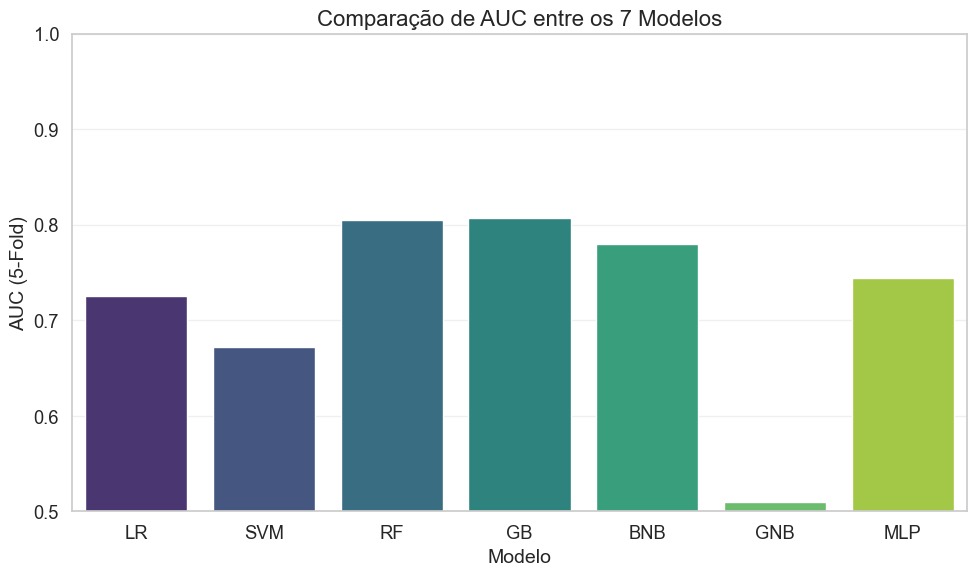


💾 Figura salva em: 5fold_PK/auc_comparacao_7modelos.png


In [37]:
# ============================================================
# COMPARAÇÃO FINAL — TODOS OS 7 MODELOS (Tabelas + Gráficos)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", font_scale=1.2)

# ============================================================
# 1) ---- MODELOS ORIGINAIS DE JAMES ----
# ============================================================

models_james = ['LR', 'SVM', 'RF', 'GB']
means_james  = [lr_mean, svm_mean, rf_mean, gb_mean]
aucs_james   = [lr_auc, svm_auc, rf_auc, gb_auc]

cv_james_list = []
for name, mean_res, auc_vals in zip(models_james, means_james, aucs_james):
    cv_james_list.append({
        'Model': name,
        'Accuracy': mean_res[0],
        'Sensitivity': mean_res[1],
        'Specificity': mean_res[2],
        'PPV': mean_res[7],
        'NPV': mean_res[8],
        'AUC': np.mean(auc_vals)
    })

df_james = pd.DataFrame(cv_james_list).round(3)

print("\n=== MODELOS ORIGINAIS (JAMES) — 5-FOLD ===")
display(df_james)


# ============================================================
# 2) ---- MODELOS NOVOS (Bernoulli, Gaussian, MLP) ----
# ============================================================

models_new = ['BNB', 'GNB', 'MLP']
means_new  = [bnb_mean, gnb_mean, mlp_mean]
aucs_new   = [bnb_auc, gnb_auc, mlp_auc]

cv_new_list = []
for name, mean_res, auc_vals in zip(models_new, means_new, aucs_new):
    cv_new_list.append({
        'Model': name,
        'Accuracy': mean_res[0],
        'Sensitivity': mean_res[1],
        'Specificity': mean_res[2],
        'PPV': mean_res[7],
        'NPV': mean_res[8],
        'AUC': np.mean(auc_vals)
    })

df_new = pd.DataFrame(cv_new_list).round(3)

print("\n=== MODELOS NOVOS (Bernoulli, Gaussian, MLP) — 5-FOLD ===")
display(df_new)


# ============================================================
# 3) ---- TABELA ÚNICA COM TODOS OS 7 MODELOS ----
# ============================================================

df_all = pd.concat([df_james, df_new], ignore_index=True)
df_all = df_all[['Model','Accuracy','Sensitivity','Specificity','PPV','NPV','AUC']]

print("\n=== TABELA FINAL — TODOS OS MODELOS ===")
display(df_all)


# ============================================================
# 4) ---- GRÁFICO COMPARATIVO (AUC) ----
# ============================================================

plt.figure(figsize=(10,6))
sns.barplot(data=df_all, x='Model', y='AUC', palette='viridis')

plt.title("Comparação de AUC entre os 7 Modelos", fontsize=16)
plt.ylabel("AUC (5-Fold)", fontsize=14)
plt.xlabel("Modelo", fontsize=14)
plt.ylim(0.5, 1.0)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("5fold_PK/auc_comparacao_7modelos.png", dpi=300)
plt.show()

print("\n💾 Figura salva em: 5fold_PK/auc_comparacao_7modelos.png")


In [38]:
np.bincount(y_final)


array([903, 160])

In [39]:
cv_summary = pd.DataFrame({
    'Model': ['LR', 'SVM', 'RF', 'GB', 'BNB', 'GNB', 'MLP'], 
    
    'Accuracy': [
        lr_mean[0], svm_mean[0], rf_mean[0], gb_mean[0],
        bnb_mean[0], gnb_mean[0], mlp_mean[0]
    ],
    
    'Sensitivity (Recall)': [
        lr_mean[1], svm_mean[1], rf_mean[1], gb_mean[1],
        bnb_mean[1], gnb_mean[1], mlp_mean[1]
    ],
    
    'Specificity': [
        lr_mean[2], svm_mean[2], rf_mean[2], gb_mean[2],
        bnb_mean[2], gnb_mean[2], mlp_mean[2]
    ],
    
    'PPV (Precision)': [
        lr_mean[7], svm_mean[7], rf_mean[7], gb_mean[7],
        bnb_mean[7], gnb_mean[7], mlp_mean[7]
    ],
    
    'NPV': [
        lr_mean[8], svm_mean[8], rf_mean[8], gb_mean[8],
        bnb_mean[8], gnb_mean[8], mlp_mean[8]
    ],
    
    'AUC': [
        np.mean(lr_auc), np.mean(svm_auc), np.mean(rf_auc), np.mean(gb_auc),
        np.mean(bnb_auc), np.mean(gnb_auc), np.mean(mlp_auc)
    ]
}).round(3)

print("\n=== MÉDIAS (5-FOLD) — COMPARAÇÃO ENTRE OS 7 MODELOS ===")
display(cv_summary)



=== MÉDIAS (5-FOLD) — COMPARAÇÃO ENTRE OS 7 MODELOS ===


,Model,Accuracy,Sensitivity (Recall),Specificity,PPV (Precision),NPV,AUC
0,LR,0.775,0.375,0.846,0.304,0.884,0.725
1,SVM,0.772,0.312,0.854,0.276,0.875,0.672
2,RF,0.849,0.194,0.966,0.610,0.871,0.805
3,GB,0.849,0.094,0.983,0.471,0.860,0.807
4,BNB,0.734,0.669,0.745,0.317,0.927,0.780
5,GNB,0.286,0.831,0.189,0.154,0.868,0.510
6,MLP,0.818,0.325,0.906,0.385,0.883,0.744


### top features



---  Análise de Importância das Features (Média dos 5 Folds) ---


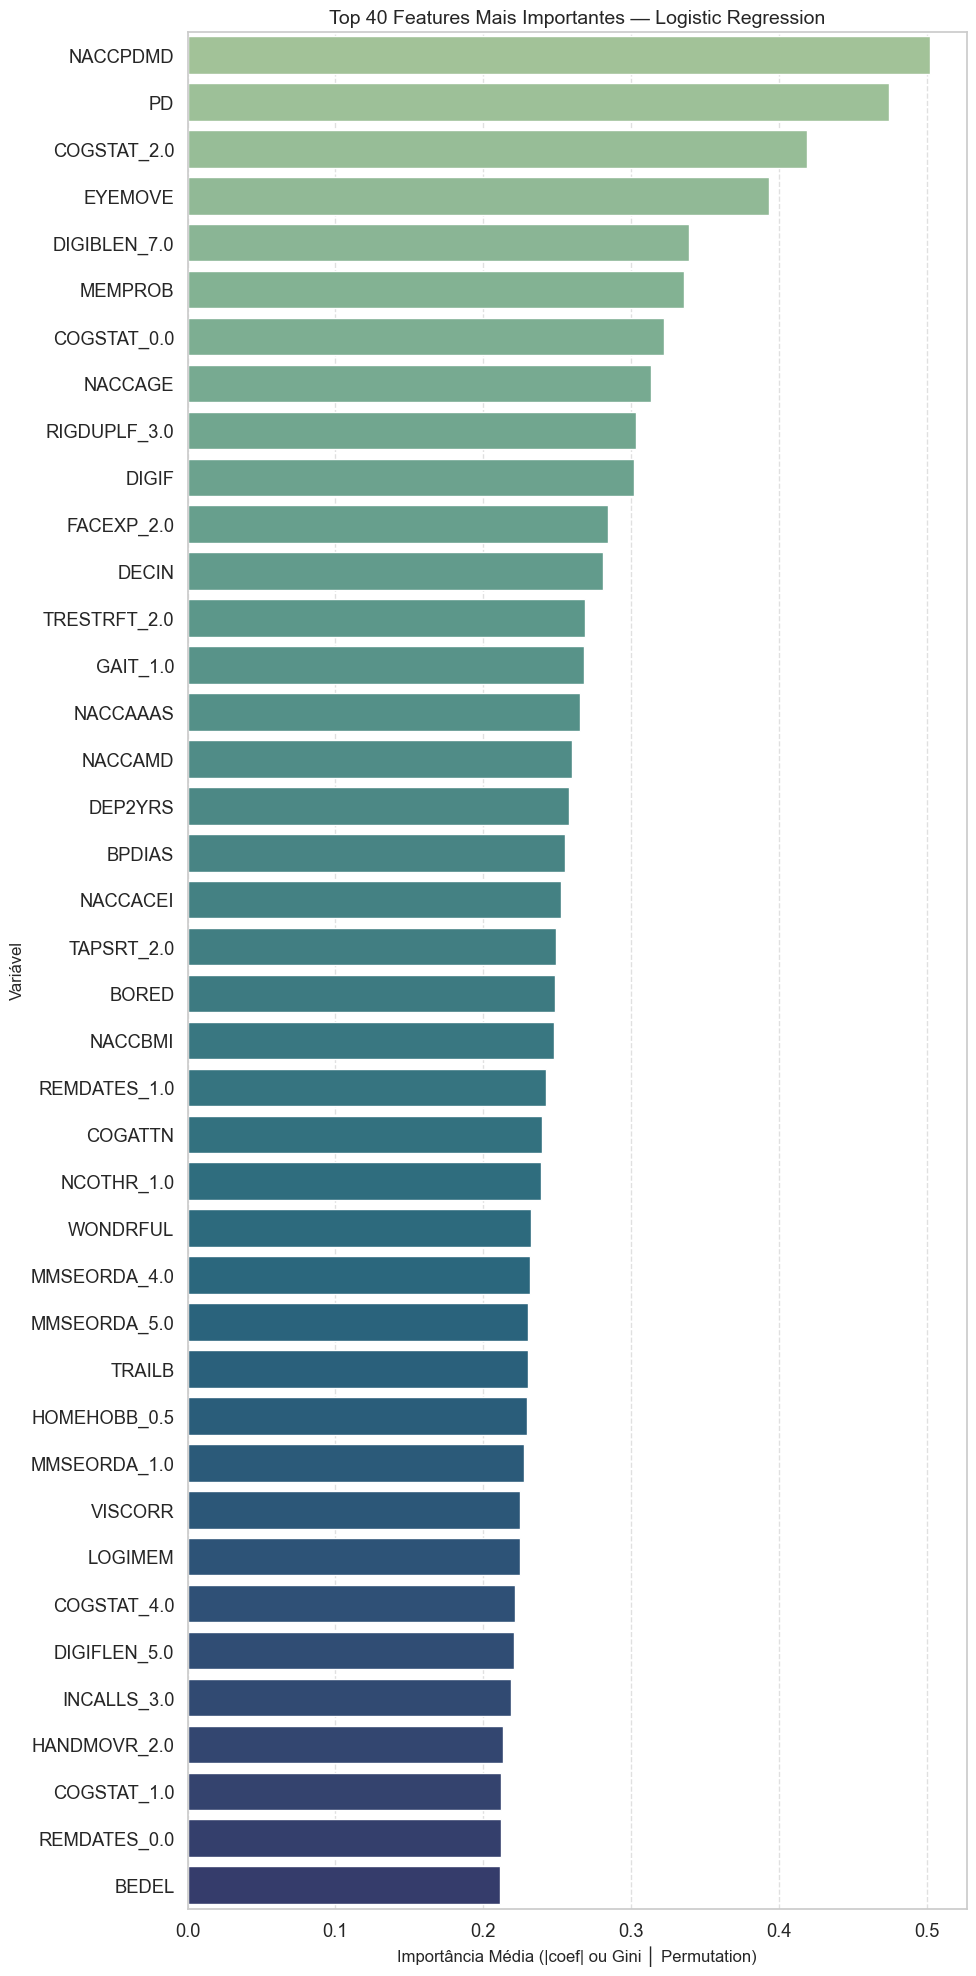

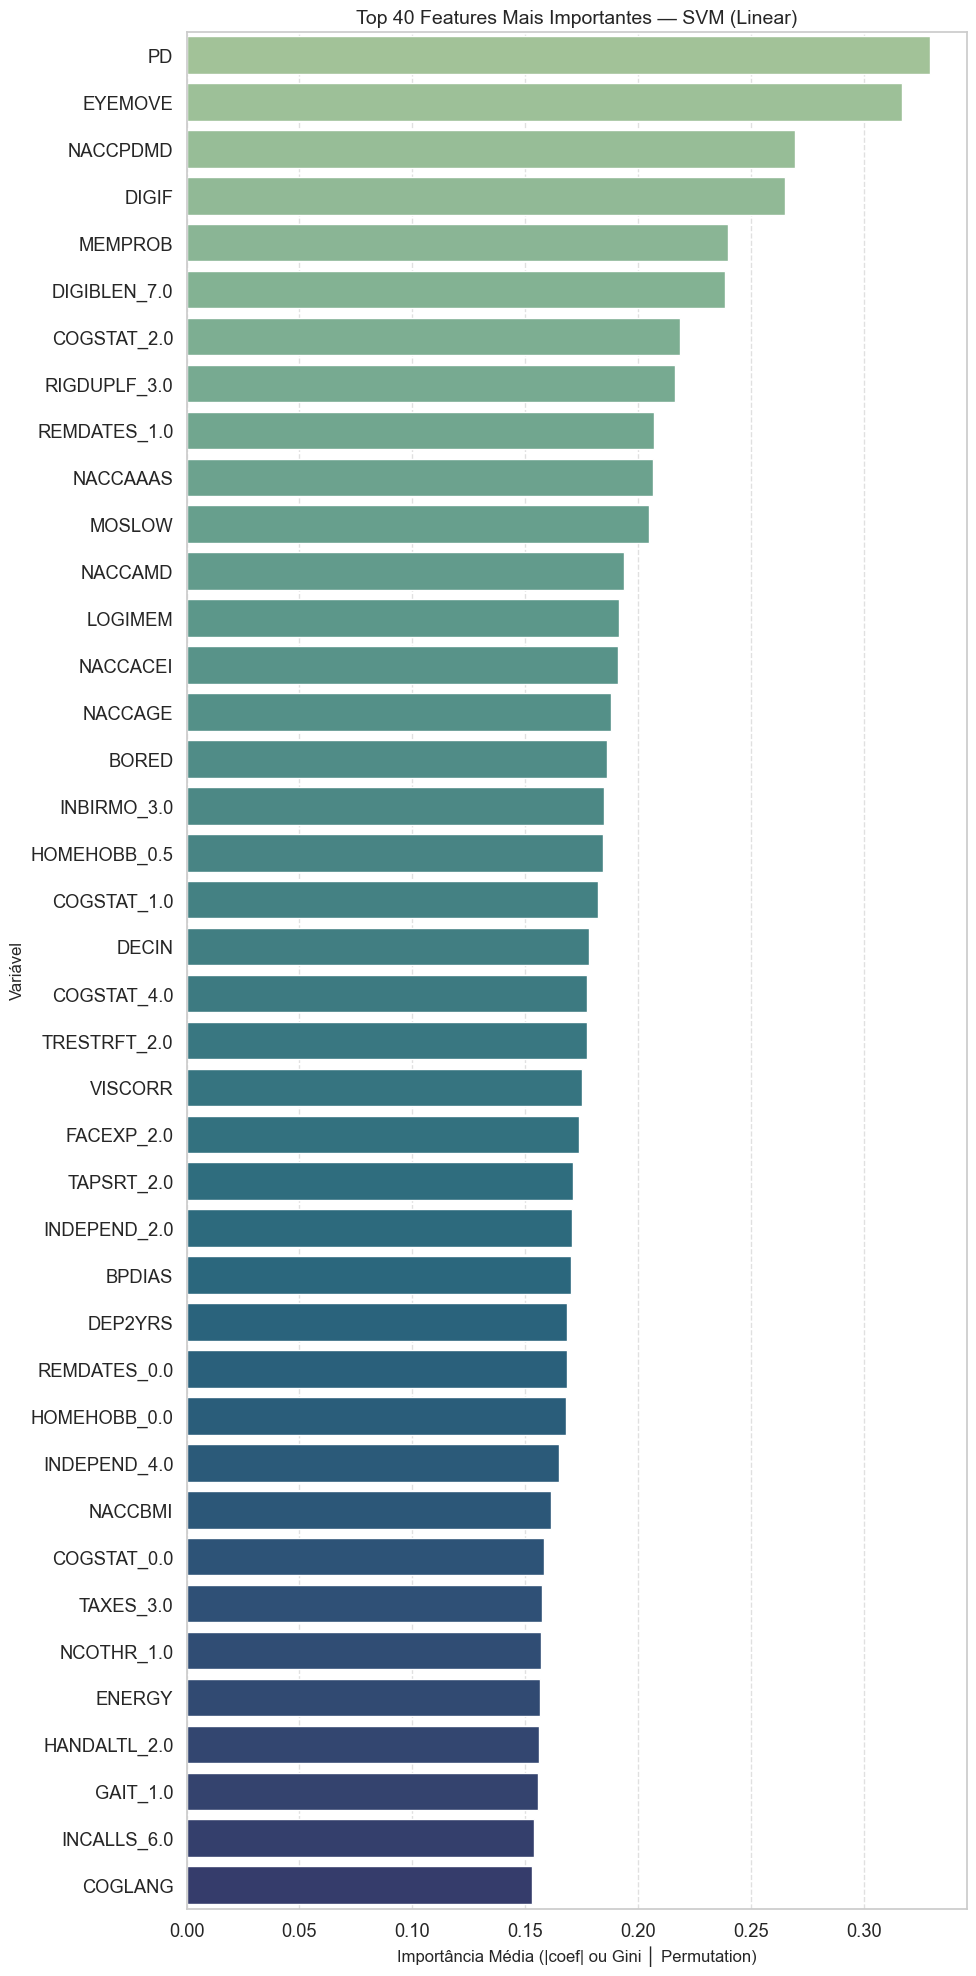

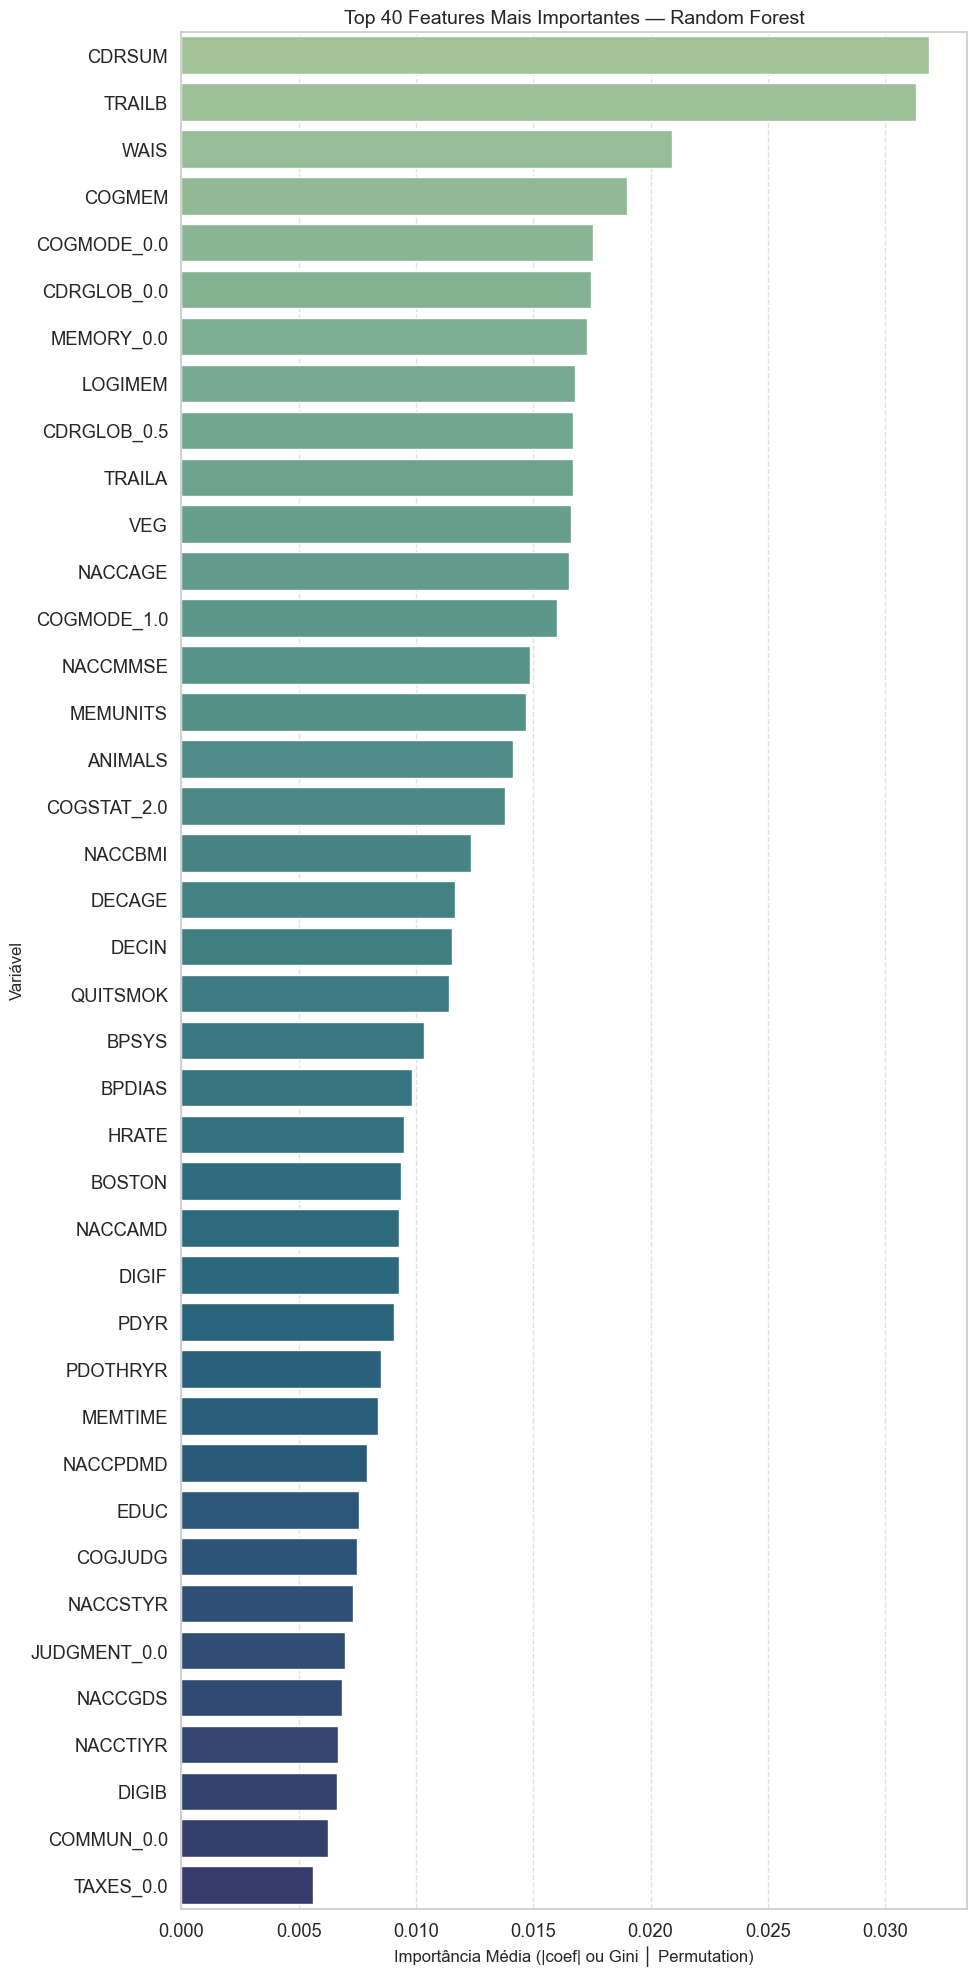

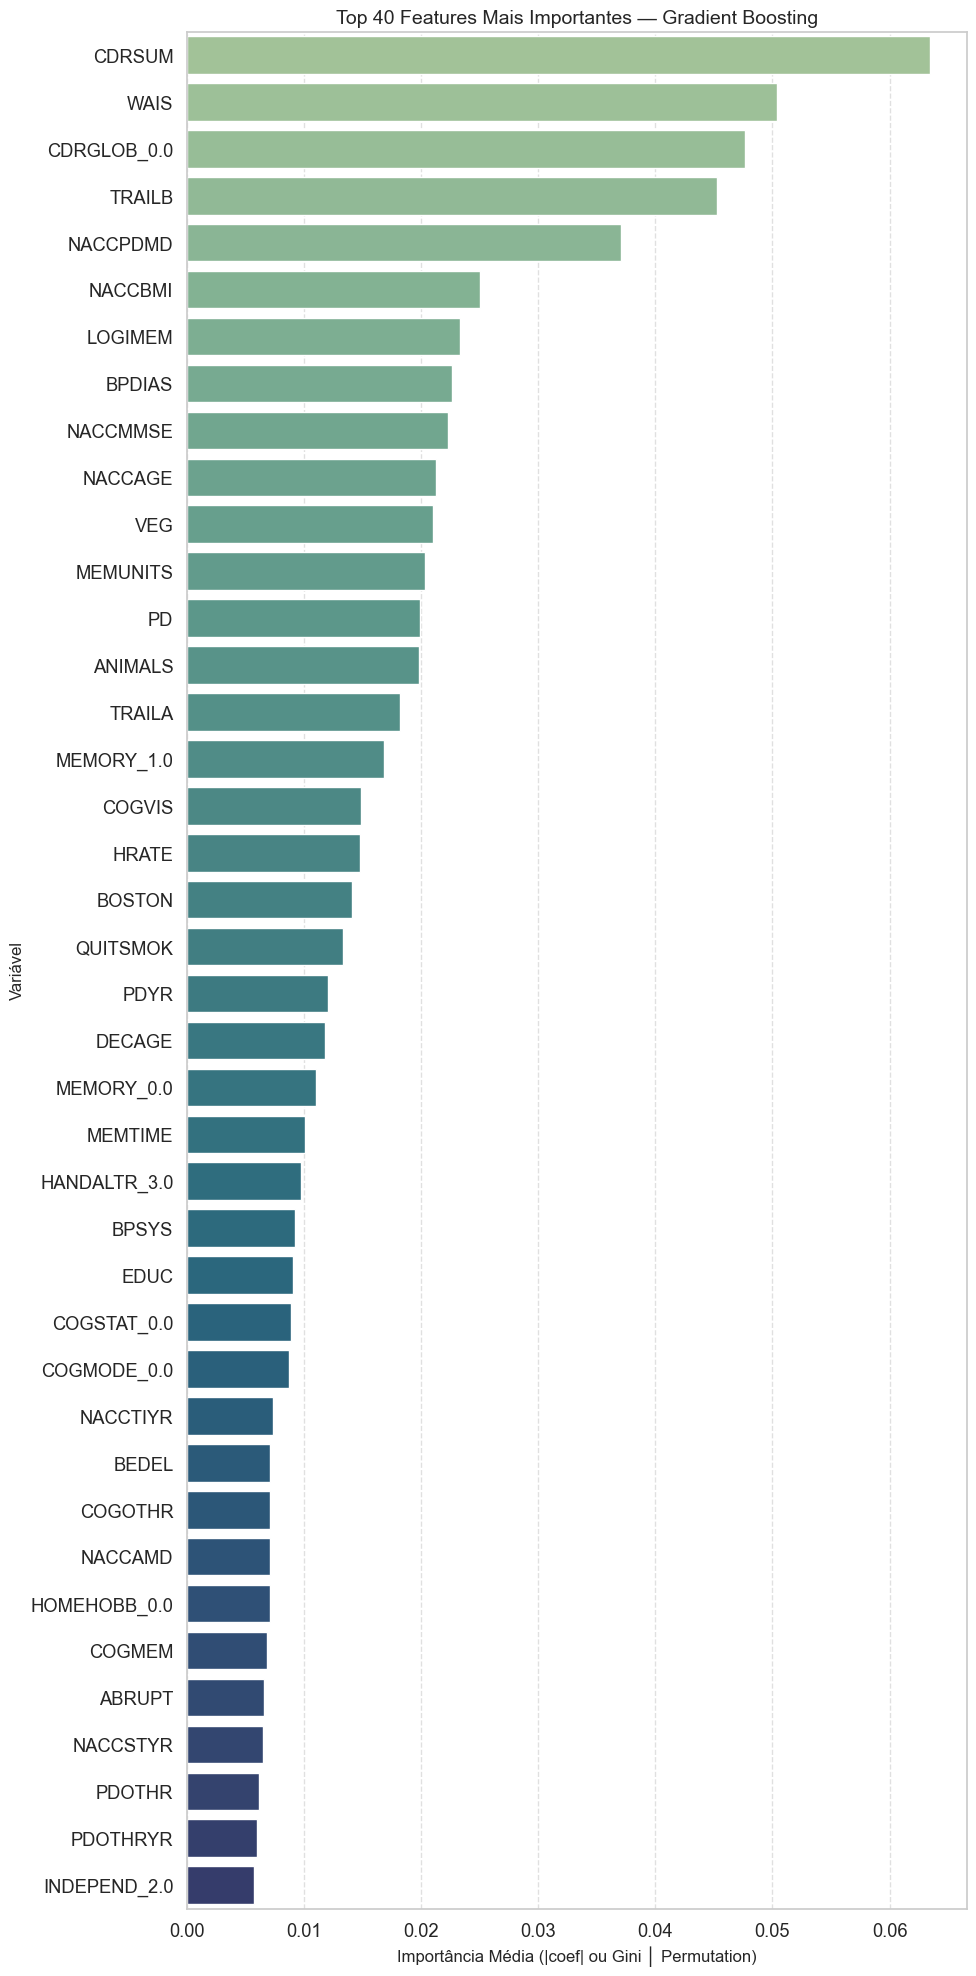

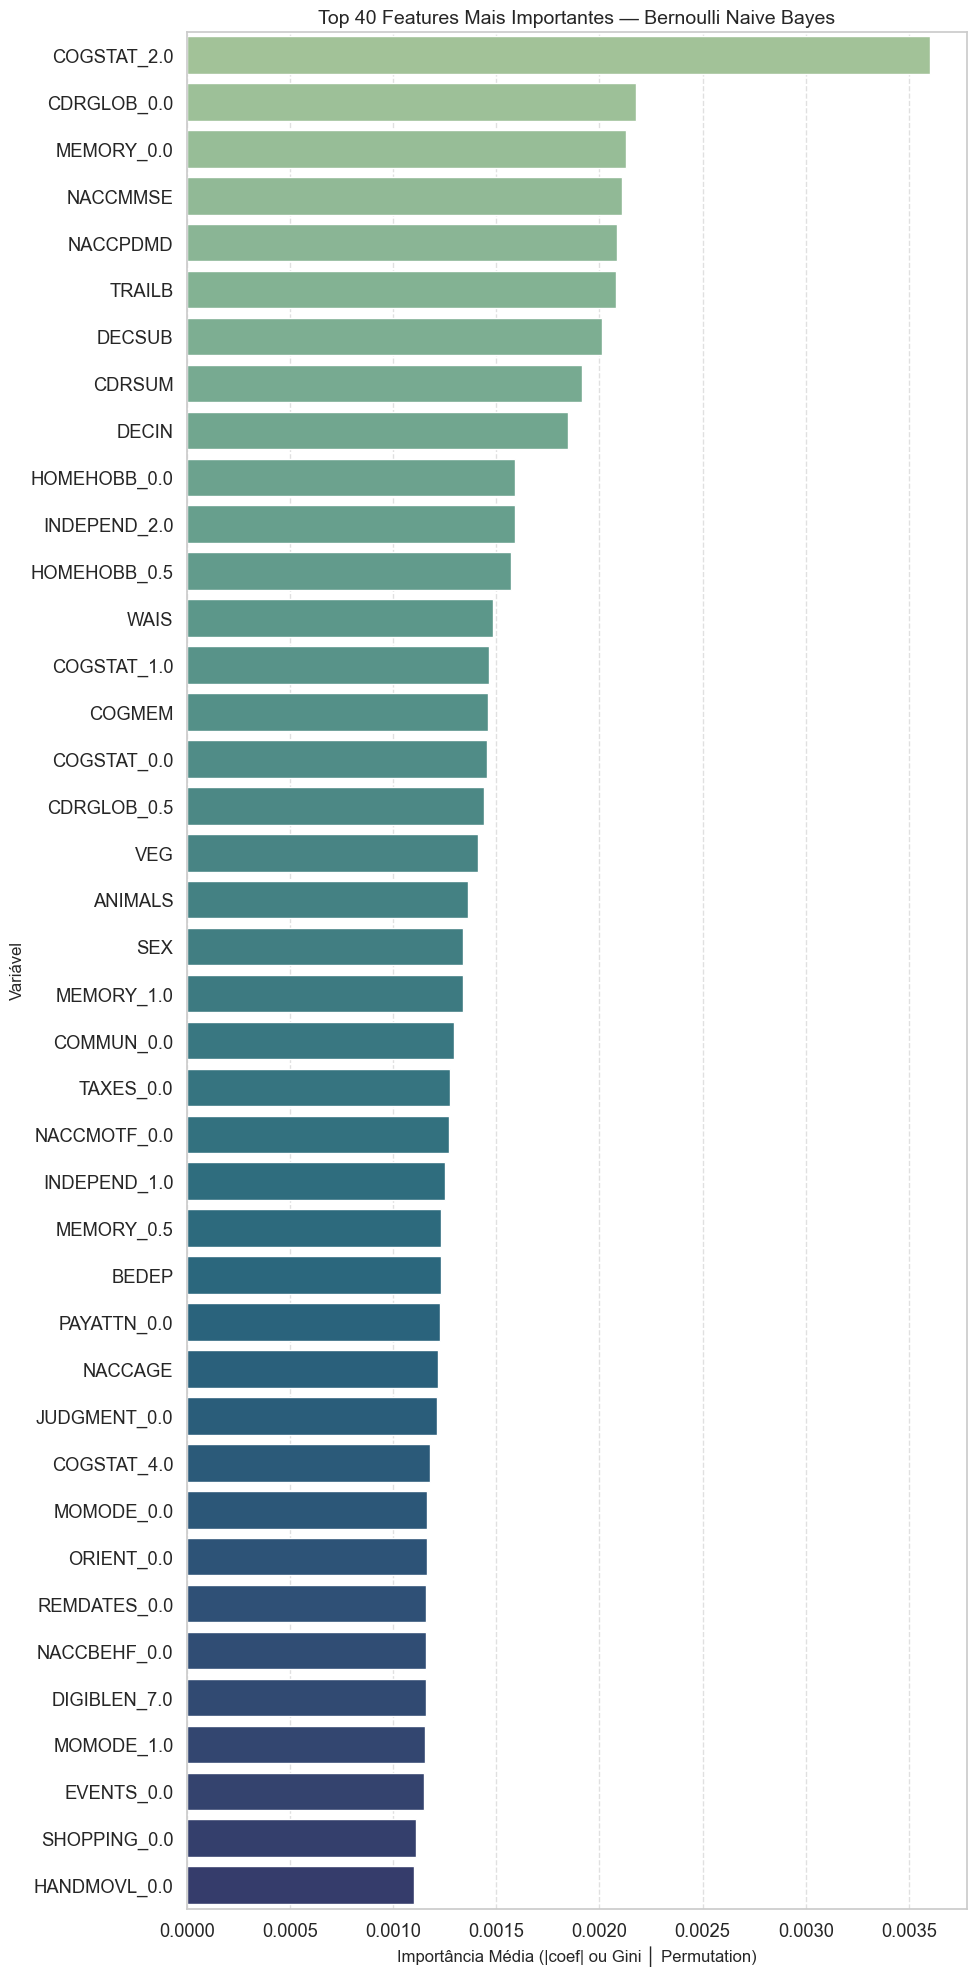

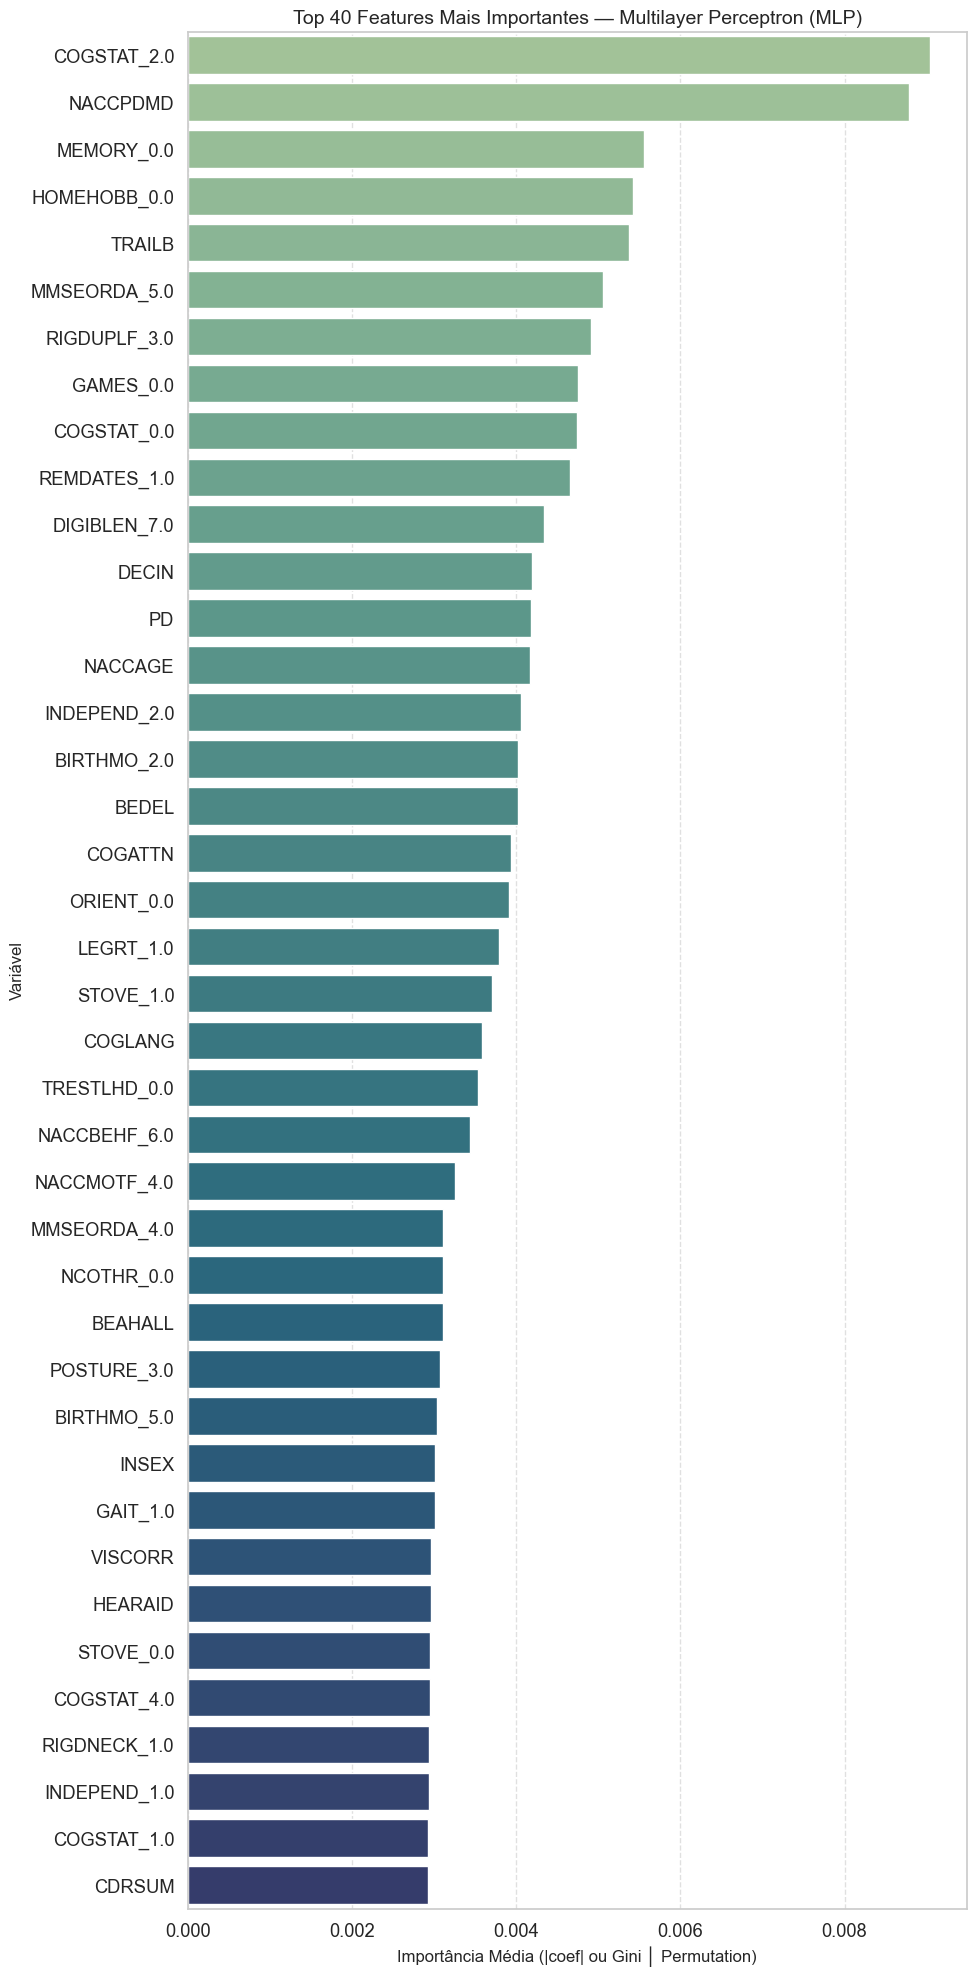

In [40]:
def analyze_and_plot_feature_importance(model_name, feature_importances_list, variable_names, top_n=40):
    
    feature_importances_array = np.array(feature_importances_list, dtype=float)
    if feature_importances_array.ndim == 1:
        feature_importances_array = feature_importances_array.reshape(1, -1)

    mean_importances = np.nanmean(np.abs(feature_importances_array), axis=0)

    if np.all(np.isnan(mean_importances)):
        print(f"❌ Não foi possível calcular a importância média para {model_name}.")
        return None

    feature_importance_df = (
        pd.DataFrame({'Feature': variable_names, 'Importance': mean_importances})
        .sort_values(by='Importance', ascending=False)
        .head(top_n)
    )

    plt.figure(figsize=(10, max(6, top_n // 2)))
    sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='crest')
    plt.title(f'Top {top_n} Features Mais Importantes — {model_name}', fontsize=14)
    plt.xlabel('Importância Média (|coef| ou Gini │ Permutation)', fontsize=12)
    plt.ylabel('Variável', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

    return feature_importance_df


print("\n---  Análise de Importância das Features (Média dos 5 Folds) ---")

# ================================
# MODELOS DE JAMES
# ================================
top_lr_features = analyze_and_plot_feature_importance(
    'Logistic Regression', lr_feat, final_variable_names
)

top_svm_features = analyze_and_plot_feature_importance(
    'SVM (Linear)', svm_feat, final_variable_names
)

top_rf_features = analyze_and_plot_feature_importance(
    'Random Forest', rf_feat, final_variable_names
)

top_gb_features = analyze_and_plot_feature_importance(
    'Gradient Boosting', gb_feat, final_variable_names
)

# ================================
# NOVOS MODELOS
# ================================

# BernoulliNB — AGORA TEM PERMUTATION IMPORTANCE
top_bnb_features = analyze_and_plot_feature_importance(
    'Bernoulli Naive Bayes', bnb_feat, final_variable_names
)

# MLP — AGORA TEM PERMUTATION IMPORTANCE
top_mlp_features = analyze_and_plot_feature_importance(
    'Multilayer Perceptron (MLP)', mlp_feat, final_variable_names
)


### analises

In [41]:
os.chdir('./5fold_PK/')  

In [42]:
import pickle as pkl

def load_data(model):
    """
    Carrega automaticamente os arquivos dentro da pasta 5fold/.
    Retorna: auc, metrics, models, err, feat, probs, preds, variables
    """
    with open(f'5fold_PK/{model}_results.pkl', 'rb') as f:
        auc, metrics, models, err, feat, probs, preds, variables = pkl.load(f)
    return auc, metrics, models, err, feat, probs, preds, variables


print("🔄 Carregando resultados dos modelos...\n")

# ================================
# MODELOS ESTILO JAMES
# ================================
rf_auc, rf_metrics, rf_models, rf_err, rf_feat, rf_probs, rf_preds, variables = load_data('rf')
lr_auc, lr_metrics, lr_models, lr_err, lr_feat, lr_probs, lr_preds, _ = load_data('lr')
svm_auc, svm_metrics, svm_models, svm_err, svm_feat, svm_probs, svm_preds, _ = load_data('svm')
gb_auc, gb_metrics, gb_models, gb_err, gb_feat, gb_probs, gb_preds, _ = load_data('xgb')

# ================================
# NOVOS MODELOS
# ================================
bnb_auc, bnb_metrics, bnb_models, bnb_err, bnb_feat, bnb_probs, bnb_preds, _ = load_data('bnb')
mlp_auc, mlp_metrics, mlp_models, mlp_err, mlp_feat, mlp_probs, mlp_preds, _ = load_data('mlp')

print("✅ Todos os modelos carregados com sucesso!")


🔄 Carregando resultados dos modelos...



FileNotFoundError: [Errno 2] No such file or directory: '5fold_PK/rf_results.pkl'

In [ ]:
data = np.load('../encoded_data_PK.npy')
outcome_PK = np.load('../outcome_PK.npy')

from sklearn.model_selection import StratifiedKFold as skf
sk = skf(n_splits=5)

true = []
for train, test in sk.split(data, outcome_PK):
    true.extend(outcome_PK[test])
true = np.array(true)


📂 Diretório de execução fixado em: /Users/eduardafigueredo/UDS
🔄 Carregando probabilidades dos modelos...
✅ Probabilidades carregadas com sucesso.
✅ Vetor verdadeiro reconstruído — 15974 amostras


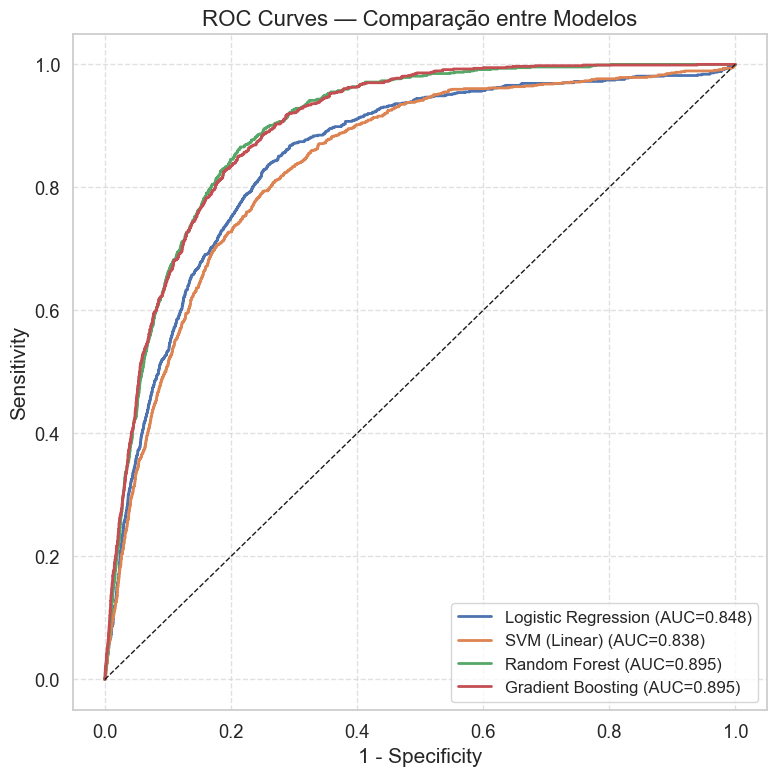

💾 Figura salva em: 5fold/compare_auc_roc_models.svg


In [ ]:
# ============================================
# ROC CURVES — COMPARAÇÃO ENTRE 7 MODELOS
# ============================================

import warnings
warnings.filterwarnings('ignore')

import os
import pickle as pkl
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.model_selection import StratifiedKFold
import seaborn as sns

sns.set(style="whitegrid", font_scale=1.2)

# ------------------------------------------------------------
# Garantir que estamos no diretório correto (UDS e não 5fold/)
# ------------------------------------------------------------
if os.path.basename(os.getcwd()) == "5fold_PK":
    os.chdir("..")
print("📌 Diretório de execução:", os.getcwd())

# ------------------------------------------------------------
# Função para carregar probabilidades
# ------------------------------------------------------------
def load_probs(model):
    with open(f'5fold_PK/{model}_results.pkl', 'rb') as f:
        auc, metrics, models, err, feat, probs, preds, _vars = pkl.load(f)
    return np.array(probs)

print("🔄 Carregando probabilidades...")

probs_lr  = load_probs('lr')
probs_svm = load_probs('svm')
probs_rf  = load_probs('rf')
probs_xgb = load_probs('xgb')
probs_bnb = load_probs('bnb')
probs_mlp = load_probs('mlp')

print("✅ Probabilidades carregadas!")

# ------------------------------------------------------------
# Reconstruir vetor verdadeiro *na mesma ordem dos probs*
# ------------------------------------------------------------
def rebuild_true_vector(outcome_PK, n_splits=5):
    sk = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    true_concat = []
    for _, test_idx in sk.split(np.zeros_like(outcome_PK), outcome_PK):
        true_concat.extend(outcome_PK[test_idx])
    return np.array(true_concat)

outcome_PK = np.load("outcome_PK.npy")
true_all = rebuild_true_vector(outcome_PK)

print(f"📌 Vetor verdadeiro reconstruído ({len(true_all)} entradas)")

# ------------------------------------------------------------
# Plot ROC style James
# ------------------------------------------------------------
def plot_roc(probs_list, true_list, labels):
    plt.figure(figsize=(9, 9))

    for prob, label in zip(probs_list, labels):
        fpr, tpr, _ = roc_curve(true_list, prob)
        auc_val = roc_auc_score(true_list, prob)
        plt.plot(fpr, tpr, linewidth=2, label=f"{label} (AUC={auc_val:.3f})")

    xx = np.linspace(0, 1, 100)
    plt.plot(xx, xx, 'k--', linewidth=1)

    plt.xlabel("1 - Specificity", fontsize=15)
    plt.ylabel("Sensitivity", fontsize=15)
    plt.title("ROC Curves — Comparação entre Modelos", fontsize=17)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(loc='lower right', fontsize=11)
    plt.tight_layout()

    plt.savefig("5fold_PK/compare_auc_roc_models.svg", dpi=300)
    plt.show()
    print("💾 Figura salva em 5fold_PK/compare_auc_roc_models.svg")


# ------------------------------------------------------------
# Lista final de modelos e rótulos
# ------------------------------------------------------------
probs = [
    probs_lr,
    probs_svm,
    probs_rf,
    probs_xgb,
    probs_bnb,
    probs_mlp
]

labels = [
    "Logistic Regression",
    "SVM (Linear)",
    "Random Forest",
    "Gradient Boosting",
    "Bernoulli Naive Bayes",
    "Gaussian Naive Bayes",
    "Multilayer Perceptron"
]

# ------------------------------------------------------------
# Gerar gráfico final
# ------------------------------------------------------------
plot_roc(probs, true_all, labels)


📂 Diretório atual: /Users/eduardafigueredo/UDS

🚀 Calculando AUC × #Features para RF...
1 features...
2 features...
3 features...
4 features...
5 features...
6 features...
7 features...
8 features...
9 features...
10 features...
11 features...
12 features...
13 features...
14 features...
15 features...
16 features...
17 features...
18 features...
19 features...
20 features...
21 features...
22 features...
23 features...
24 features...
25 features...
26 features...
27 features...
28 features...
29 features...
30 features...
31 features...
32 features...
33 features...
34 features...
35 features...
36 features...
37 features...
38 features...
39 features...
40 features...
💾 Arquivo salvo: 5fold/rf_auc_low_hi_med.npy


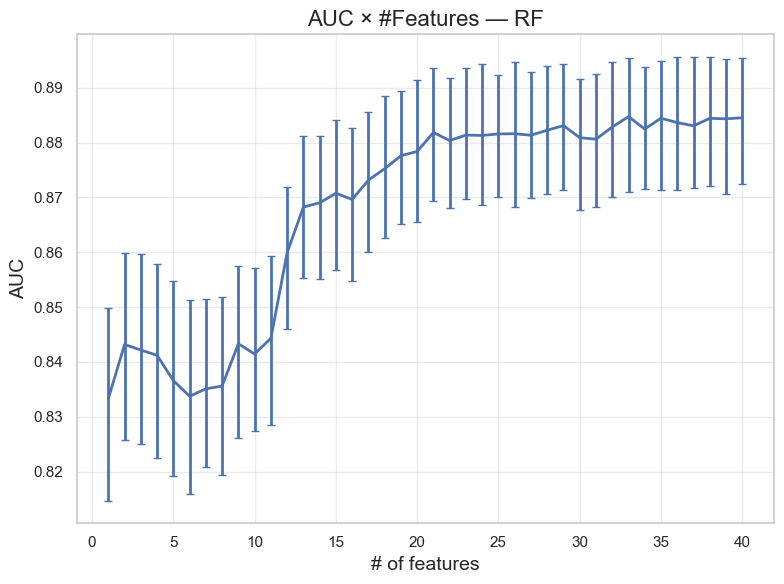


🚀 Calculando AUC × #Features para LR...
1 features...
2 features...
3 features...
4 features...
5 features...
6 features...
7 features...
8 features...
9 features...
10 features...
11 features...
12 features...
13 features...
14 features...
15 features...
16 features...
17 features...
18 features...
19 features...
20 features...
21 features...
22 features...
23 features...
24 features...
25 features...
26 features...
27 features...
28 features...
29 features...
30 features...
31 features...
32 features...
33 features...
34 features...
35 features...
36 features...
37 features...
38 features...
39 features...
40 features...
💾 Arquivo salvo: 5fold/lr_auc_low_hi_med.npy


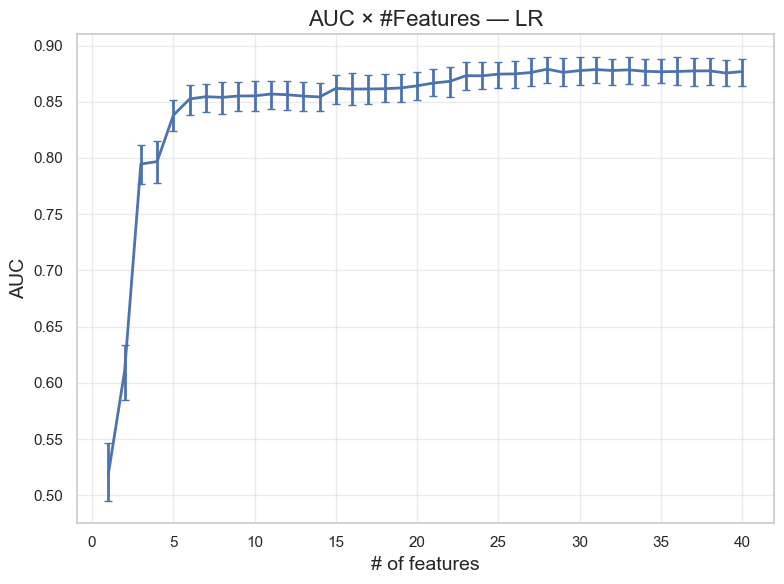


🚀 Calculando AUC × #Features para SVM...
1 features...
2 features...
3 features...
4 features...
5 features...
6 features...
7 features...
8 features...
9 features...
10 features...
11 features...
12 features...
13 features...
14 features...
15 features...
16 features...
17 features...
18 features...
19 features...
20 features...
21 features...
22 features...
23 features...
24 features...
25 features...
26 features...
27 features...
28 features...
29 features...
30 features...
31 features...
32 features...
33 features...
34 features...
35 features...
36 features...
37 features...
38 features...
39 features...
40 features...
💾 Arquivo salvo: 5fold/svm_auc_low_hi_med.npy


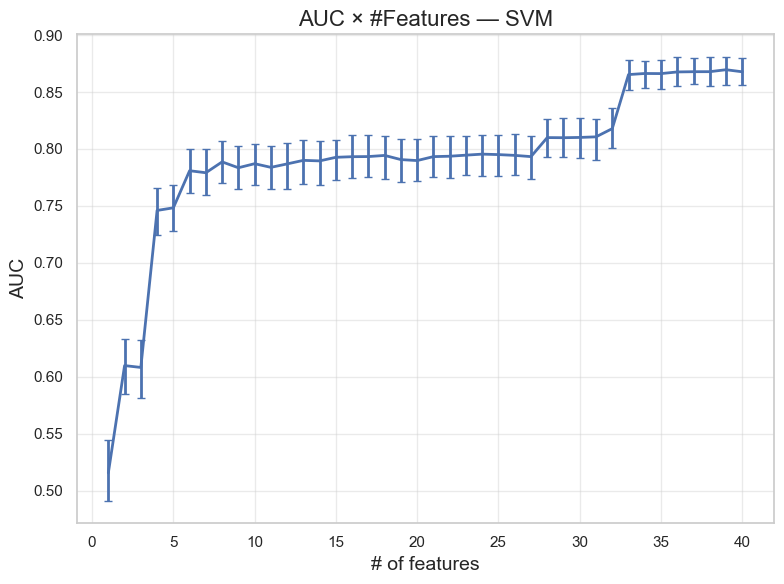


🚀 Calculando AUC × #Features para XGB...
1 features...
2 features...
3 features...
4 features...
5 features...
6 features...
7 features...
8 features...
9 features...
10 features...
11 features...
12 features...
13 features...
14 features...
15 features...
16 features...
17 features...
18 features...
19 features...
20 features...
21 features...
22 features...
23 features...
24 features...
25 features...
26 features...
27 features...
28 features...
29 features...
30 features...
31 features...
32 features...
33 features...
34 features...
35 features...
36 features...
37 features...
38 features...
39 features...
40 features...
💾 Arquivo salvo: 5fold/xgb_auc_low_hi_med.npy


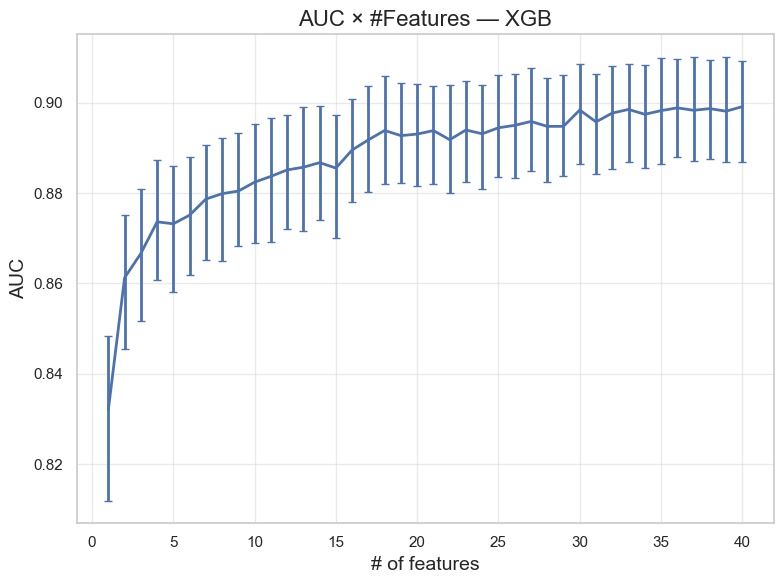

In [ ]:
os.makedirs('5fold_PK', exist_ok=True)
print("📂 Diretório atual:", os.getcwd())


def bootstrap_auc(probability, classes, n_iter=1000, sample_size=1000):
    auc_vals = []
    n = len(classes)
    for _ in range(n_iter):
        selection = np.random.randint(0, n, size=min(sample_size, n))
        probs = np.array(probability)[selection]
        true = np.array(classes)[selection]
        auc_vals.append(roc_auc_score(true, probs))
    return np.percentile(auc_vals, 25), np.percentile(auc_vals, 75), np.median(auc_vals)


def auc_feat(models, feat_importance, X_data, y_data, n_features=40):
    idx = np.argsort(-feat_importance)  
    sk = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    auc_vals, lows, highs, meds = [], [], [], []

    for i in range(1, n_features + 1):
        print(f"{i} features...")
        feats = idx[:i]
        probs, true = [], []
        count = 0

        for train_idx, test_idx in sk.split(X_data, y_data):
            model = models[count]
            X_train = X_data[train_idx][:, feats]
            X_test  = X_data[test_idx][:, feats]
            y_train = y_data[train_idx]
            y_test  = y_data[test_idx]

            model.fit(X_train, y_train)
            prob = model.predict_proba(X_test)[:, 1]

            probs.extend(prob)
            true.extend(y_test)
            count += 1

        auc_val = roc_auc_score(true, probs)
        l, h, m = bootstrap_auc(probs, true)
        auc_vals.append(auc_val)
        lows.append(l)
        highs.append(h)
        meds.append(m)

    return auc_vals, lows, meds, highs


models_info = {
    'rf':  '5fold_PK/rf_results.pkl',
    'lr':  '5fold_PK/lr_results.pkl',
    'svm': '5fold_PK/svm_results.pkl',
    'xgb': '5fold_PK/xgb_results.pkl',
    'bnb': '5fold_PK/bnb_results.pkl',   # ✔ Bernoulli Naive Bayes — válido
    'mlp': '5fold_PK/mlp_results.pkl' 
}

X_final = np.load('encoded_data_PK.npy')
y_final = np.load('outcome_PK.npy')


for short_name, file_path in models_info.items():
    with open(file_path, 'rb') as f:
        auc, metrics, models, err, feat, probs, preds, variables = pickle.load(f)
    
    print(f"\n🚀 Calculando AUC × #Features para {short_name.upper()}...")

    mean_feat = np.mean(feat, axis=0)
    a, l, m, h = auc_feat(models, mean_feat, X_final, y_final, n_features=40)

    np.save(f'5fold_PK/{short_name}_auc_low_hi_med.npy', [a, l, m, h])
    print(f"💾 Arquivo salvo: 5fold_PK/{short_name}_auc_low_hi_med.npy")

    x = list(range(1, 41))
    plt.figure(figsize=(8, 6))
    plt.errorbar(
        x, m,
        yerr=np.vstack((np.array(m) - np.array(l), np.array(h) - np.array(m))),
        alpha=1, linewidth=2, capsize=3
    )
    plt.xlabel('# of features', fontsize=14)
    plt.ylabel('AUC', fontsize=14)
    plt.title(f'AUC × #Features — {short_name.upper()}', fontsize=16)
    plt.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.savefig(f'5fold_PK/{short_name}_auc_vs_features.png', dpi=300)
    plt.show()


In [ ]:
# =============================================================
#   FORÇANDO NAIVE BAYES A ENTRAR NO AUC × Nº DE FEATURES
# =============================================================

from sklearn.naive_bayes import GaussianNB
import numpy as np
import pickle
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

print("\n⚠️ Rodando NB com importâncias artificiais (apenas para teste)")

# -------------------------------------------------------------
# 1) Carregar dados e modelo (GaussianNB já treinado)
# -------------------------------------------------------------
with open("5fold_PK/nb_results.pkl", "rb") as f:
    nb_auc, nb_metrics, nb_models, nb_err, nb_feat, nb_probs, nb_preds, variables = pickle.load(f)

X_final = np.load("encoded_data.npy")
y_final = np.load("outcome_PK.npy")

# -------------------------------------------------------------
# 2) Criar importâncias FAKE (todas iguais)
# -------------------------------------------------------------
fake_feat_importance = np.ones(X_final.shape[1])

print(f"✔ Importâncias artificiais criadas: {len(fake_feat_importance)} features")

# -------------------------------------------------------------
# 3) Função para curva AUC × Nº Features (igual à sua)
# -------------------------------------------------------------
def bootstrap_auc(probability, classes, n_iter=1000, sample_size=1000):
    auc_vals = []
    n = len(classes)
    for _ in range(n_iter):
        idx = np.random.randint(0, n, size=min(sample_size, n))
        auc_vals.append(roc_auc_score(classes[idx], probability[idx]))
    auc_vals = np.array(auc_vals)
    return np.percentile(auc_vals, 25), np.percentile(auc_vals, 75), np.median(auc_vals)


def auc_feat(models, feat_importance, X_data, y_data, n_features=40):
    idx = np.argsort(-feat_importance)  # <- aqui usamos as importâncias FAKE
    sk = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    auc_vals, lows, highs, meds = [], [], [], []

    for i in range(1, n_features + 1):
        print(f"{i} features...")
        feats = idx[:i]

        probs = []
        true = []
        count = 0

        for train_idx, test_idx in sk.split(X_data, y_data):
            model = models[count]

            X_train = X_data[train_idx][:, feats]
            X_test  = X_data[test_idx][:, feats]

            y_train = y_data[train_idx]
            y_test  = y_data[test_idx]

            # NB agora treina apenas no subconjunto (mesmo que isso seja inválido cientificamente)
            model.fit(X_train, y_train)
            prob = model.predict_proba(X_test)[:, 1]

            probs.extend(prob)
            true.extend(y_test)
            count += 1

        auc_val = roc_auc_score(true, probs)
        l, h, m = bootstrap_auc(np.array(probs), np.array(true))

        auc_vals.append(auc_val)
        lows.append(l)
        highs.append(h)
        meds.append(m)

    return auc_vals, lows, meds, highs


# -------------------------------------------------------------
# 4) Rodar curva AUC × Nº Features com NB forçado
# -------------------------------------------------------------
a, l, m, h = auc_feat(nb_models, fake_feat_importance, X_final, y_final, n_features=40)

np.save("5fold_PK/nb_forced_auc_low_hi_med.npy", [a, l, m, h])
print("\n💾 Arquivo salvo: 5fold_PK/nb_forced_auc_low_hi_med.npy")

# -------------------------------------------------------------
# 5) Plot simples
# -------------------------------------------------------------
import matplotlib.pyplot as plt

x = list(range(1, 41))
plt.figure(figsize=(8,6))
plt.errorbar(x, m, 
             yerr=np.vstack((np.array(m)-np.array(l), np.array(h)-np.array(m))), 
             capsize=3, linewidth=2)
plt.xlabel('Top-K Features (forçado)')
plt.ylabel('AUC')
plt.title('AUC × Nº Features — Naive Bayes (forçado)')
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

print("\n⚠️ Importante: Estes resultados NÃO são válidos cientificamente — apenas teste técnico.")


🔄 Carregando importâncias...
Importâncias carregadas com sucesso!

Top 40 variáveis por modelo extraídas:


,LR,SVM,RF,XGB
0,COGSTAT_0.0,COGSTAT_0.0,CDRSUM,CDRSUM
1,NACCAGE,NACCAGE,COGMODE_0.0,MEMUNITS
2,COGSTAT_1.0,CDRSUM,CDRGLOB_0.0,COGMODE_0.0
3,NACCTBI,COGSTAT_2.0,COGMODE_1.0,VEG
4,COGSTAT_2.0,COGSTAT_1.0,COGMEM,LOGIMEM
5,DECIN,TOBAC100,MEMUNITS,NACCMMSE
6,NPSYLAN_2.0,DECIN,TRAILB,TRAILB
7,NPSYLAN_1.0,NPSYLAN_2.0,MEMORY_0.0,COGMODE_1.0
8,COGMODE_0.0,COGMODE_0.0,DECIN,EDUC
9,COGMODE_1.0,NPSYLAN_1.0,CDRGLOB_0.5,NACCBMI


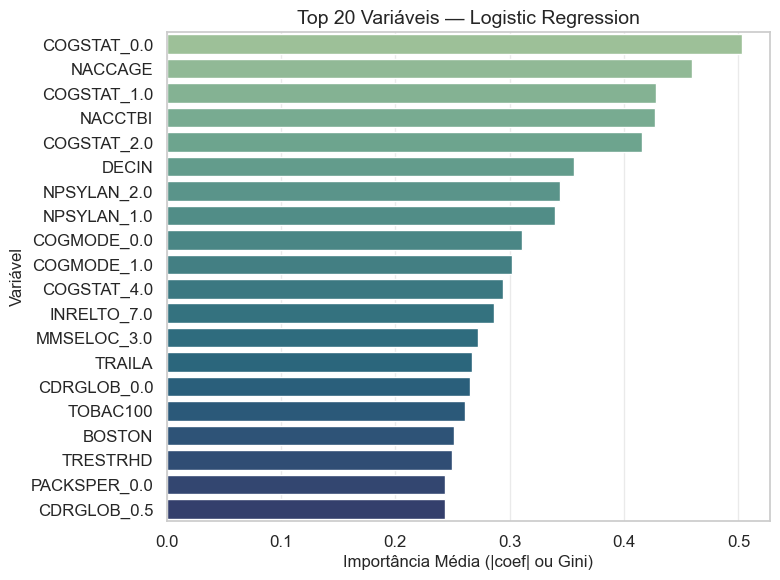

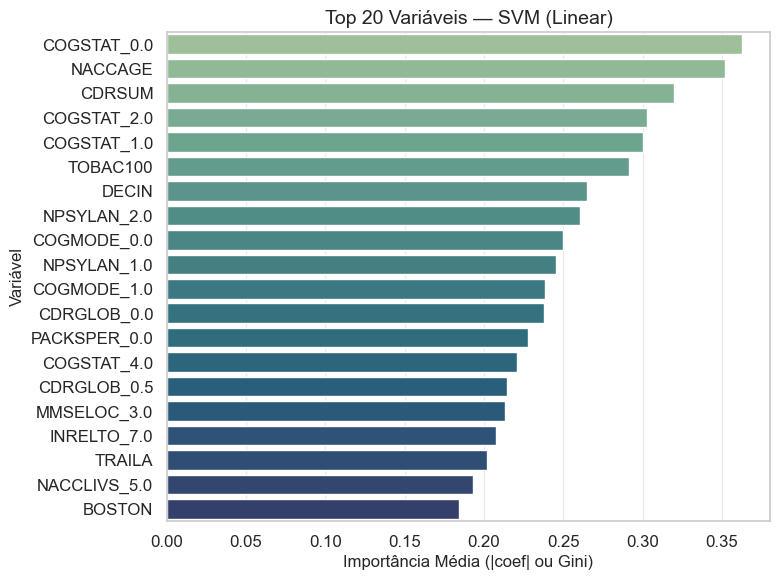

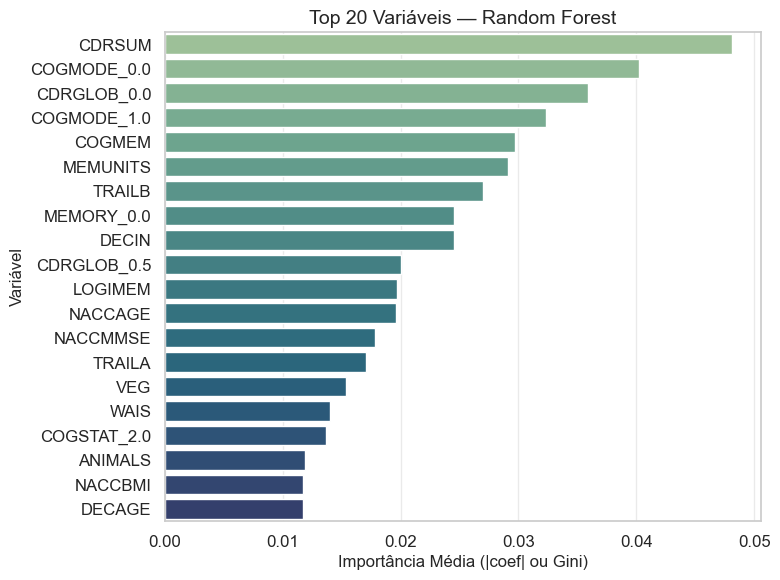

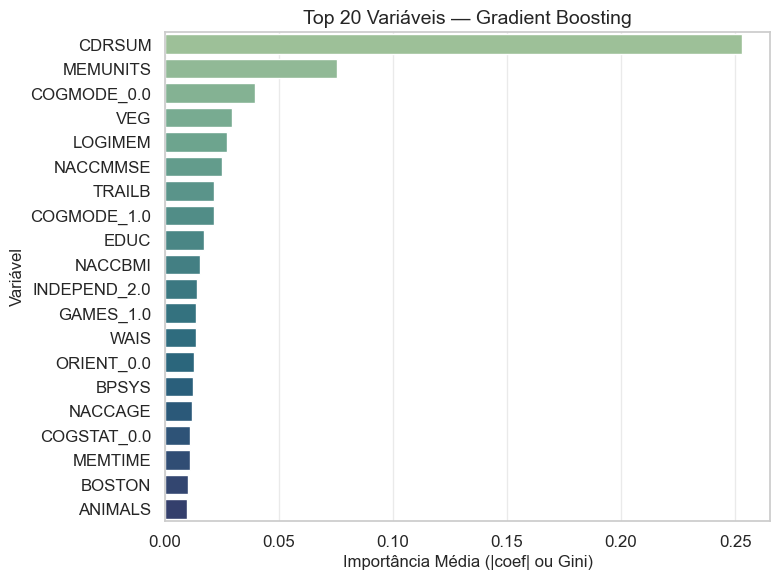

In [ ]:
sns.set(style="whitegrid", font_scale=1.1)

def load_feature_importances(model):
    with open(f'5fold_PK/{model}_results.pkl', 'rb') as f:
        auc, metrics, models, err, feat, probs, preds, variables = pkl.load(f)
    return feat, variables

print("🔄 Carregando importâncias...")

# Modelos de James
lr_feat, variables = load_feature_importances('lr')
svm_feat, _        = load_feature_importances('svm')
rf_feat, _         = load_feature_importances('rf')
xgb_feat, _        = load_feature_importances('xgb')

# Novos modelos
bnb_feat, _        = load_feature_importances('bnb')   # BernoulliNB # GaussianNB
mlp_feat, _        = load_feature_importances('mlp')   # MLP

print("✅ Importâncias carregadas com sucesso!\n")

def importances_df(models, importances, n_feat, variables):
    features = pd.DataFrame()
    for m, imp in zip(models, importances):
        imp_mean = np.mean(np.abs(imp), axis=0)  
        idx_sorted = np.argsort(-imp_mean)      
        top_vars = [variables[i] for i in idx_sorted[:n_feat]]
        features[m] = top_vars
    return features

# Lista de modelos (rótulos bonitinhos) e respectivos arrays de importâncias
models = ['LR', 'SVM', 'RF', 'XGB', 'BNB', 'MLP']
importances = [lr_feat, svm_feat, rf_feat, xgb_feat, bnb_feat, mlp_feat]

features_df = importances_df(models, importances, n_feat=40, variables=variables)

print("Top 40 variáveis por modelo extraídas:")
display(features_df.head(10))

def plot_feature_importance(model_name, feat_list, variables, top_n=20, color='royalblue'):
    imp_mean = np.mean(np.abs(feat_list), axis=0)
    idx_sorted = np.argsort(-imp_mean)[:top_n]
    top_vars = np.array(variables)[idx_sorted]
    top_scores = imp_mean[idx_sorted]

    plt.figure(figsize=(8, 6))
    sns.barplot(x=top_scores, y=top_vars, palette='crest')
    plt.title(f'Top {top_n} Variáveis — {model_name}', fontsize=14)
    plt.xlabel('Importância Média (|coef| ou similar)', fontsize=12)
    plt.ylabel('Variável', fontsize=12)
    plt.grid(axis='x', alpha=0.4)
    plt.tight_layout()
    plt.show()

# Você pode plotar só os que têm importância mais interpretável:
plot_feature_importance('Logistic Regression', lr_feat,  variables)
plot_feature_importance('SVM (Linear)',        svm_feat, variables)
plot_feature_importance('Random Forest',       rf_feat,  variables)
plot_feature_importance('Gradient Boosting',   xgb_feat, variables)
plot_feature_importance('Naive bAYES',   bnb_feat, variables)
plot_feature_importance('Multilayer Perceptron (MLP)', mlp_feat, variables)

# Se quiser também ver NB (sabendo que pode ser menos interpretável):
# plot_feature_importance('Bernoulli Naive Bayes', bnb_feat, variables)
# plot_feature_importance('Gaussian Naive Bayes',  gnb_feat, variables)


📂 Arquivos encontrados: ['svm_auc_low_hi_med.npy', 'lr_auc_low_hi_med.npy', 'xgb_auc_low_hi_med.npy', 'rf_auc_low_hi_med.npy']


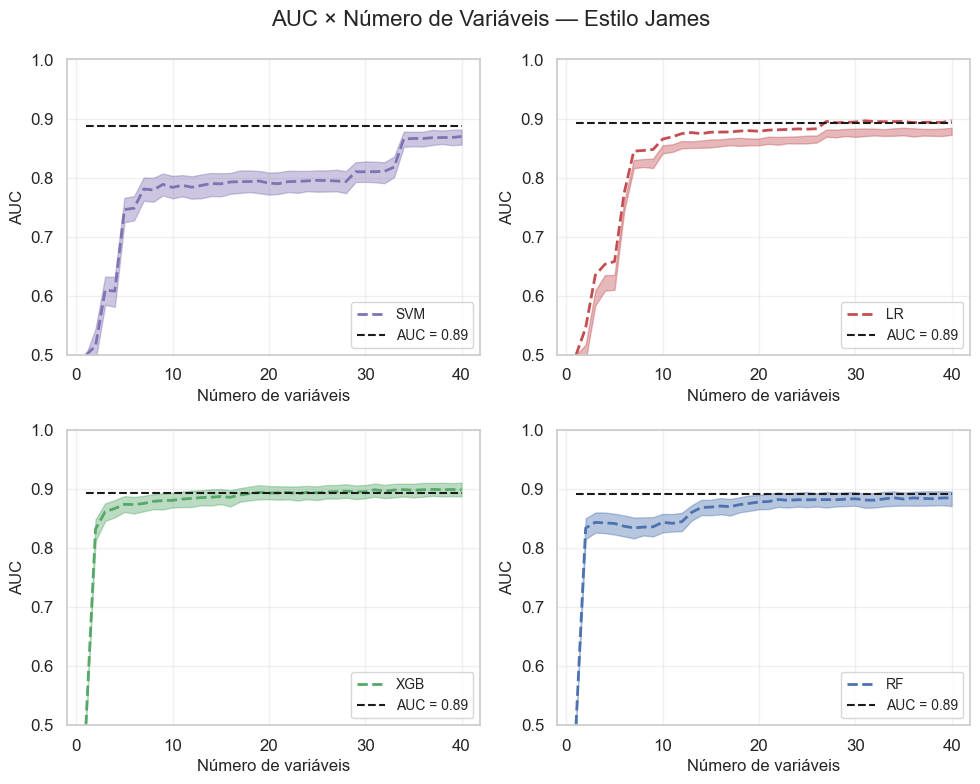

💾 Figura salva em: 5fold/auc_vs_features_all.png


In [ ]:
valid_models = ['lr', 'svm', 'rf', 'xgb', 'mlp']

files = [
    f for f in os.listdir('5fold_PK')
    if f.endswith('_auc_low_hi_med.npy') and f.split('_')[0] in valid_models
]
print(f"Arquivos encontrados: {files}")

auc_vals, low, high, med, name = [], [], [], [], []
for f in files:
    a, l, m, h = np.load(os.path.join('5fold_PK', f), allow_pickle=True)
    a, l, m, h = [np.concatenate(([0.5], x)) for x in [a, l, m, h]]
    auc_vals.append(a)
    low.append(l)
    high.append(h)
    med.append(m)
    name.append(f.split('_')[0])

short2name = {
    'lr': 'LR',
    'svm': 'SVM',
    'rf': 'RF',
    'xgb': 'XGB',
    'mlp': 'MLP'
}

colors = {
    'lr': 'r',
    'svm': 'm',
    'rf': 'b',
    'xgb': 'g',
    'mlp': 'orange'
}

short2auc = {
    'rf': np.mean(rf_auc),
    'lr': np.mean(lr_auc),
    'svm': np.mean(svm_auc),
    'xgb': np.mean(gb_auc),
    'mlp': np.mean(mlp_auc)
}

def plot_auc_feat(auc, low, med, high, name, i, col, ax):
    a, l, h, m = auc[i][:40], low[i][:40], high[i][:40], med[i][:40]
    x = list(range(1, len(a) + 1))
    ax.plot(x, m, '--', linewidth=2, color=col, label=short2name[name[i]])
    ax.fill_between(x, l, h, alpha=0.4, color=col)
    ax.plot(x, np.ones(len(x)) * short2auc[name[i]], 'k--',
            label=f"AUC = {short2auc[name[i]]:.2f}")
    ax.set_ylim(0.5, 1)
    ax.set_xlabel('Número de variáveis', fontsize=12)
    ax.set_ylabel('AUC', fontsize=12)
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(alpha=0.3)

fig = plt.figure(figsize=(12, 10))
spec = gridspec.GridSpec(ncols=2, nrows=3, figure=fig)

for i in range(len(files)):
    ax = fig.add_subplot(spec[i])
    col = colors[name[i]]
    plot_auc_feat(auc_vals, low, med, high, name, i, col, ax)

plt.suptitle('AUC × Número de Variáveis — Estilo James (5 Modelos)', fontsize=18)
plt.tight_layout()
plt.savefig('5fold_PK/auc_vs_features_all.png', dpi=300)
plt.show()

print("  Figura salva em: 5fold_PK/auc_vs_features_all.png")


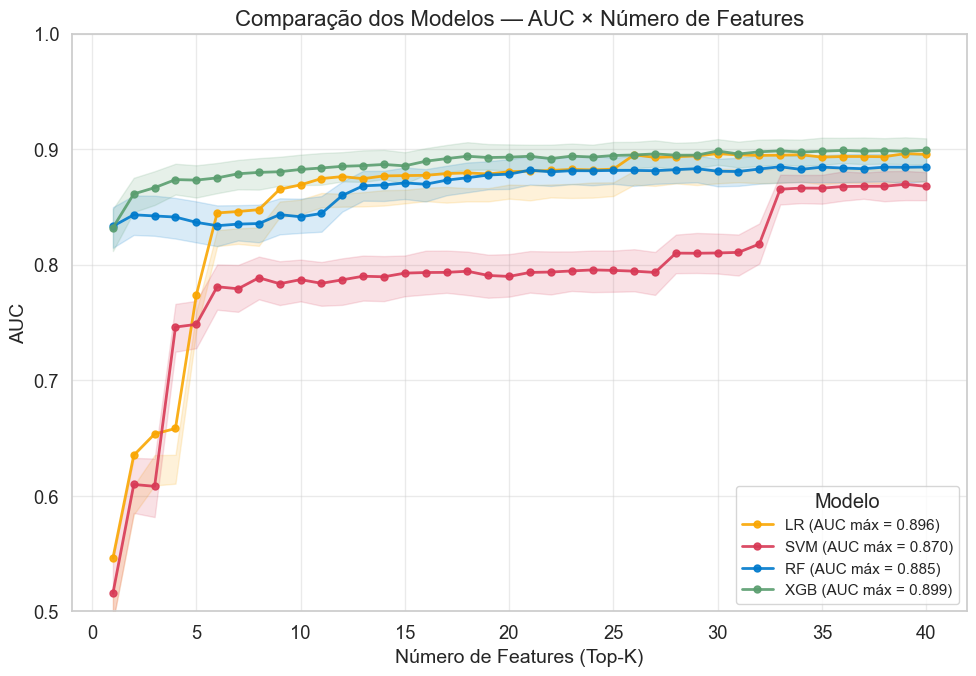


💾 Figura salva em: 5fold/auc_vs_features_comparison.png


In [ ]:
sns.set(style="whitegrid", font_scale=1.2)

result_dir = "5fold_PK"

# Agora com 5 modelos
models = ['LR', 'SVM', 'RF', 'XGB', 'MLP']

colors = {
    'LR': '#F9A602',
    'SVM': '#D83A56',
    'RF': '#007ACC',
    'XGB': '#5A9E6F',
    'MLP': '#9B59B6'
}

files = {
    'LR':  os.path.join(result_dir, 'lr_auc_low_hi_med.npy'),
    'SVM': os.path.join(result_dir, 'svm_auc_low_hi_med.npy'),
    'RF':  os.path.join(result_dir, 'rf_auc_low_hi_med.npy'),
    'XGB': os.path.join(result_dir, 'xgb_auc_low_hi_med.npy'),
    'MLP': os.path.join(result_dir, 'mlp_auc_low_hi_med.npy')
}

plt.figure(figsize=(10, 7))

for model in models:
    auc_vals, low, med, high = np.load(files[model], allow_pickle=True)
    x = np.arange(1, len(med) + 1)

    plt.plot(
        x, med, '-o',
        linewidth=2,
        markersize=5,
        alpha=0.9,
        color=colors[model],
        label=f"{model} (AUC máx = {max(med):.3f})"
    )

    plt.fill_between(
        x, low, high,
        color=colors[model],
        alpha=0.15
    )

plt.xlabel('Número de Features (Top-K)', fontsize=14)
plt.ylabel('AUC', fontsize=14)
plt.title('Comparação dos Modelos — AUC × Número de Features', fontsize=16)
plt.ylim(0.5, 1.0)
plt.legend(title='Modelo', fontsize=11, loc='lower right')
plt.grid(alpha=0.4)
plt.tight_layout()

save_path = os.path.join(result_dir, "auc_vs_features_comparison.png")
plt.savefig(save_path, dpi=300)
plt.show()

print(f"\nFigura salva em: {save_path}")


In [ ]:
import pandas as pd
import numpy as np

# ============================================================
#   FUNÇÃO PARA OBTER TOP-K VARIÁVEIS POR MODELO
# ============================================================

def get_top_variables(feat_list, variable_names, top_k=40):
    feat_array = np.array(feat_list)

    # Caso seja 1D, reshape para compatibilidade
    if feat_array.ndim == 1:
        feat_array = feat_array.reshape(1, -1)

    # importância média
    imp_mean = np.mean(np.abs(feat_array), axis=0)

    # ordenar desc
    idx_sorted = np.argsort(-imp_mean)

    # selecionar top K
    top_vars = [variable_names[i] for i in idx_sorted[:top_k]]

    return top_vars


# ============================================================
#   CARREGAR IMPORTÂNCIAS DOS MODELOS
# ============================================================

# James
models_feat = {
    'LR': lr_feat,
    'SVM': svm_feat,
    'RF': rf_feat,
    'GB': gb_feat,
}

# Novos
models_feat.update({
    'BNB': bnb_feat,         # Bernoulli        # Gaussian
    'MLP': mlp_feat          # MLP
})

# Nome das variáveis
variables = final_variable_names


# ============================================================
#   GERAR DICIONÁRIO: MODELO → LISTA DE TOP VARIÁVEIS
# ============================================================

top_k = 40   # você pode alterar para 20, 50 etc.

top_vars_dict = {}

for model_name, feat_list in models_feat.items():
    top_vars_dict[model_name] = get_top_variables(feat_list, variables, top_k=top_k)


# ============================================================
#   CONTAR RECORRÊNCIAS ENTRE MODELOS
# ============================================================

# Junta todas as variáveis e conta frequência
all_vars = []

for vlist in top_vars_dict.values():
    all_vars.extend(vlist)

var_counts = pd.Series(all_vars).value_counts()


# ============================================================
#   CRIA TABELA FINAL
# ============================================================

df_recorrencia = (
    var_counts
    .reset_index()
    .rename(columns={'index': 'Variável', 0: 'Frequência'})
)

print("\n📌 TABELA — Variáveis mais recorrentes entre modelos (TOP-40)")
display(df_recorrencia.head(20))

# Se quiser salvar
df_recorrencia.to_csv("5fold_PK/variaveis_recorrentes.csv", index=False)
print("\n💾 Tabela salva em: 5fold_PK/variaveis_recorrentes.csv")
